# Pathogen Research in Meat Production: Comprehensive Dashboard
## How Animal Welfare Practices Impact Food Safety

**Project Objective:** Analyze the relationship between animal handling practices and pathogen contamination in meat products

**Story:** This dashboard explores whether caring for animals better might reduce pathogen contamination rates, ultimately protecting human health.

**Analysis Date:** March 2026  
**Data Period:** FY2025 (USDA FSIS data), 2017-2018 (Consumption data)

---

## Table of Contents

1. [Data Sources & Limitations](#section-1)
2. [Foods People Eat: Plant vs Animal](#section-2)
3. [Pathogen Contamination in Animal Products](#section-3)
4. [Recalls: When Contamination Reaches Consumers](#section-4)
5. [Animal Welfare Practices (GCP Inspections)](#section-5)
6. [The Connection: Welfare & Contamination](#section-6)
7. [Key Findings & Recommendations](#section-7)

---

<a id='section-1'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 1: DATA SOURCES & LIMITATIONS
# ═══════════════════════════════════════════════════════════════════

In [41]:
# Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully")
print(f"Analysis date: {datetime.now().strftime('%Y-%m-%d')}")

✓ Libraries imported successfully
Analysis date: 2026-04-12


### Data Sources Overview

### Configure Data Paths

**Note:** If running in Google Colab, uncomment the COLAB_DATA_PATH line and comment out DATA_PATH.

In [42]:
# Configure data paths
# For Google Colab: uncomment the next line and comment out DATA_PATH
# COLAB_DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/listeria-tracker/data'
# DATA_PATH = COLAB_DATA_PATH

# For local execution: use relative path
DATA_PATH = '../data'

print(f"✓ Data path configured: {DATA_PATH}")

✓ Data path configured: ../data


In [43]:
# Define data sources
data_sources = {
    'Consumption Data': {
        'file': 'data/usFoodGroupIntakesBySource.csv',
        'period': '1977-2018',
        'latest': '2017-2018',
        'description': 'USDA food intake survey - what Americans eat',
        'coverage': 'Plant and animal products'
    },
    'Lab Sampling - Raw Pork': {
        'file': 'data/labSamplingRawPorkFy2025.json',
        'period': 'FY2025 (Oct 2024-Sep 2025)',
        'description': 'Pathogen testing of raw pork products',
        'coverage': 'Animal products only'
    },
    'Lab Sampling - Raw Poultry': {
        'file': 'data/labSamplingRawPoultryFy2025.json',
        'period': 'FY2025 (Oct 2024-Sep 2025)',
        'description': 'Pathogen testing of raw poultry products',
        'coverage': 'Animal products only'
    },
    'Lab Sampling - Ready-to-Eat': {
        'file': 'data/labSamplingRteFy2025.json',
        'period': 'FY2025 (Oct 2024-Sep 2025)',
        'description': 'Pathogen testing of RTE meat products',
        'coverage': 'Animal products only'
    },
    'GCP Inspections': {
        'file': 'data/gcpArchiveFy2025.csv',
        'period': 'FY2025 (Oct 2024-Sep 2025)',
        'description': 'Good Commercial Practices - animal welfare inspections',
        'coverage': 'Poultry slaughter facilities'
    },
    'Recall Data (API)': {
        'file': 'data/processed/recallsApiFY2025.csv',
        'period': 'FY2025 (Oct 2024-Sep 2025)',
        'description': 'Listeria & Salmonella recalls from FSIS API - FY2025 aligned',
        'coverage': 'Animal products only'
    }
}

# Display data sources table
sources_df = pd.DataFrame(data_sources).T
print("\n" + "="*80)
print("DATA SOURCES")
print("="*80)
for source, info in data_sources.items():
    print(f"\n{source}:")
    print(f"  File: {info['file']}")
    print(f"  Period: {info['period']}")
    print(f"  Coverage: {info['coverage']}")
print("="*80)


DATA SOURCES

Consumption Data:
  File: data/usFoodGroupIntakesBySource.csv
  Period: 1977-2018
  Coverage: Plant and animal products

Lab Sampling - Raw Pork:
  File: data/labSamplingRawPorkFy2025.json
  Period: FY2025 (Oct 2024-Sep 2025)
  Coverage: Animal products only

Lab Sampling - Raw Poultry:
  File: data/labSamplingRawPoultryFy2025.json
  Period: FY2025 (Oct 2024-Sep 2025)
  Coverage: Animal products only

Lab Sampling - Ready-to-Eat:
  File: data/labSamplingRteFy2025.json
  Period: FY2025 (Oct 2024-Sep 2025)
  Coverage: Animal products only

GCP Inspections:
  File: data/gcpArchiveFy2025.csv
  Period: FY2025 (Oct 2024-Sep 2025)
  Coverage: Poultry slaughter facilities

Recall Data (API):
  File: data/processed/recallsApiFY2025.csv
  Period: FY2025 (Oct 2024-Sep 2025)
  Coverage: Animal products only


### Understanding the Establishments & Data Collection

**What are these facilities?**
- **Poultry slaughter and processing plants** regulated by USDA FSIS
- Include chicken and turkey processing facilities
- Range from small operations to large industrial plants
- All must have continuous USDA inspection presence during operations

**How are they evaluated?**

**1. Good Commercial Practices (GCP) Inspections:**
- **Who:** USDA FSIS inspectors (federal employees)
- **What:** Monitor animal welfare during slaughter - humane handling, stunning, welfare violations
- **When:** Continuous - inspectors are present during all operating hours
- **Documentation:** 
  - **MOI (Memorandum of Interview)**: Discussion record for animal welfare concerns - documents issues but may not rise to penalty level
  - **NR (Non-Compliance Record)**: Official violation documentation for food safety or animal welfare failures
- **FY2025 Data:** 94,120 total inspections across 242 establishments

**2. Laboratory Sampling (Pathogen Testing):**
- **Who:** USDA FSIS Food Safety Assessment (FSA) staff
- **What:** Collect samples of raw products for Salmonella, Listeria, and other pathogen testing
- **When:** Regular sampling schedule (frequency varies by establishment size/risk)
- **Where Tested:** FSIS laboratories
- **FY2025 Data:** Focus on raw poultry (chicken, turkey), raw pork, and ready-to-eat meat products

**How is the data linked?**
- Both GCP and Lab data are keyed by **Establishment Number** (e.g., "M18502", "P-7089")
- This allows correlation of animal welfare practices (GCP) with contamination rates (Lab)
- **242 establishments** had both GCP and Lab data in FY2025 - this is our analysis sample
- Additional establishments may have one dataset but not the other

**Why this matters:**
- Same federal inspectors who monitor animal welfare also oversee food safety
- Establishments with poor management may show problems in both areas
- The hypothesis: better animal treatment → healthier animals → safer food

### ⚠️ CRITICAL DATA GAP: Plant-Based Products

**Missing Data:**
- ❌ No pathogen lab sampling for plant-based products (vegetables, fruits, grains)
- ❌ No plant-based product recalls in FSIS data (falls under FDA jurisdiction)
- ❌ Cannot perform fair comparison of animal vs plant contamination rates

**Why This Matters:**
- FSIS (Food Safety Inspection Service) only regulates meat, poultry, and fish
- FDA (Food and Drug Administration) regulates produce and plant-based products
- This analysis focuses on **animal products only** due to data availability

**Implication for Analysis:**
- We can show contamination rates IN animal products
- We can correlate animal welfare practices WITH contamination
- We **cannot** claim animal products are "more contaminated than plants" without plant data

<a id='section-2'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 2: FOODS PEOPLE EAT - PLANT VS ANIMAL
# ═══════════════════════════════════════════════════════════════════

## Understanding What Americans Consume

Before analyzing contamination, we need to understand consumption patterns. This establishes context for the public health impact of contamination.

In [44]:
# Load consumption data
consumption_df = pd.read_csv(f'{DATA_PATH}/usFoodGroupIntakesBySource.csv')

print("✓ Consumption data loaded")
print(f"  Records: {len(consumption_df):,}")
print(f"  Columns: {consumption_df.columns.tolist()}")

✓ Consumption data loaded
  Records: 109,368
  Columns: ['Food group', 'Food source', 'Measurement', 'Food group:Food source', 'Survey years:Variable', 'Value', 'Table', 'Demographics']


In [45]:
# Define plant vs animal categories
animal_keywords = ['meat', 'poultry', 'eggs', 'seafood', 'fish', 'dairy', 'cured']
plant_keywords = ['vegetable', 'fruit', 'grain', 'legume', 'nut', 'seed', 'soy']

def categorize_food_source(food_group):
    """Categorize as plant, animal, or other"""
    if pd.isna(food_group):
        return 'Other'
    food_lower = str(food_group).lower()

    for keyword in animal_keywords:
        if keyword in food_lower:
            return 'Animal'

    for keyword in plant_keywords:
        if keyword in food_lower:
            return 'Plant'

    return 'Other'

# Helper function to handle spacing inconsistencies in food group names
def should_include(food_group):
    if pd.isna(food_group):
        return False
    fg = str(food_group).strip()

    # Include aggregate totals for these categories
    if fg in ['Dairy, total', 'Fruit, total', 'Vegetable, total', 'Grains, total']:
        return True

    # For proteins: include detailed items but exclude aggregates
    if 'Protein foods,' in fg:
        # Exclude these aggregate rows to avoid double-counting
        if fg in ['Protein foods, total', 'Protein foods, meats, poultry, and fish']:
            return False
        # Include specific protein items
        return True

    return False

# Filter for 2017-2018 mean data
consumption_recent = consumption_df[
    (consumption_df['Survey years:Variable'] == '2017-2018-Mean') &
    (consumption_df['Demographics'] == 'US consumers aged 2 and above') &
    (consumption_df['Food source'] == 'Total')
].copy()

# Apply filter using helper function
consumption_recent = consumption_recent[
    consumption_recent['Food group'].apply(should_include) &
    (consumption_recent['Food group'] != 'Energy ')
].copy()

# Categorize by food type
consumption_recent['food_type'] = consumption_recent['Food group'].apply(categorize_food_source)

# Group by food type and measurement unit
consumption_summary = consumption_recent.groupby(['food_type', 'Measurement'])['Value'].sum().reset_index()
consumption_summary.columns = ['food_type', 'unit', 'daily_amount']
consumption_summary['annual_amount'] = consumption_summary['daily_amount'] * 365

print("\n" + "="*80)
print("US Food Consumption (2017-2018) - USDA MyPlate Equivalents")
print("="*80)
print("\nNote: USDA uses 'cup equivalents' for fruits, vegetables, dairy")
print("      and 'ounce equivalents' for grains and proteins.")
print("      Proteins are split: Animal (meat/poultry/fish/eggs) vs Plant (nuts/seeds/soy)")
print("="*80)

for food_type in ['Plant', 'Animal', 'Other']:
    data = consumption_summary[consumption_summary['food_type'] == food_type]
    if len(data) > 0:
        print(f"\n{food_type.upper()} FOODS:")
        for _, row in data.iterrows():
            unit_label = "cups" if 'Cup' in row['unit'] else "oz"
            print(f"  {row['daily_amount']:6.2f} {unit_label}/day  |  {row['annual_amount']:7.1f} {unit_label}/year")
print("="*80)

# Show what foods are included
print("\nFOOD CATEGORIES INCLUDED:")
for food_type in ['Plant', 'Animal', 'Other']:
    foods = consumption_recent[consumption_recent['food_type'] == food_type]['Food group'].tolist()
    if foods:
        print(f"\n{food_type}:")
        for food in sorted(set([f.strip() for f in foods])):
            print(f"  • {food}")


US Food Consumption (2017-2018) - USDA MyPlate Equivalents

Note: USDA uses 'cup equivalents' for fruits, vegetables, dairy
      and 'ounce equivalents' for grains and proteins.
      Proteins are split: Animal (meat/poultry/fish/eggs) vs Plant (nuts/seeds/soy)

PLANT FOODS:
    2.32 cups/day  |    846.8 cups/year
    7.45 oz/day  |   2719.2 oz/year

ANIMAL FOODS:
    1.53 cups/day  |    558.5 cups/year
    5.03 oz/day  |   1836.0 oz/year

FOOD CATEGORIES INCLUDED:

Plant:
  • Fruit, total
  • Grains, total
  • Protein foods, nuts and seeds
  • Protein foods, soy products
  • Vegetable, total

Animal:
  • Dairy, total
  • Protein foods, cured meat
  • Protein foods, eggs
  • Protein foods, high Omega-3 fatty fish
  • Protein foods, low Omega-3 fatty fish
  • Protein foods, meats (beef, veal, pork, lamb, game)
  • Protein foods, organ meats
  • Protein foods, poultry


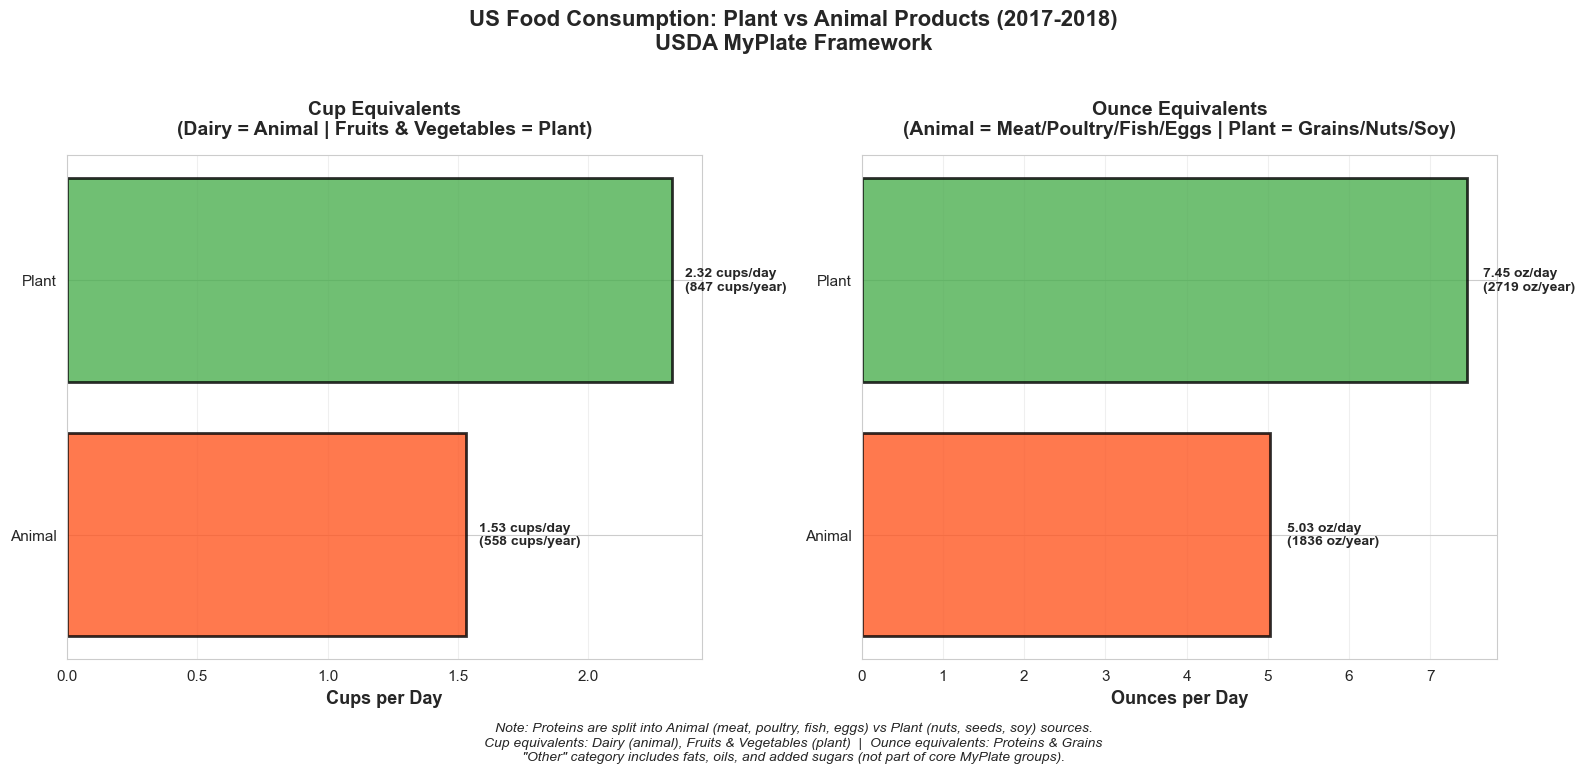


✓ GRAPH 1: Plant vs Animal consumption


In [46]:
# GRAPH 1: Create visualization for plant vs animal consumption using USDA MyPlate equivalents
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_dict = {'Plant': '#4CAF50', 'Animal': '#FF5722', 'Other': '#9E9E9E'}

# Left panel: Cup equivalents (Fruits, Vegetables, Dairy)
cup_data = consumption_summary[consumption_summary['unit'].str.contains('Cup', case=False, na=False)].copy()
if len(cup_data) > 0:
    cup_data = cup_data.sort_values('daily_amount', ascending=True)
    bars_cups = axes[0].barh(
        cup_data['food_type'],
        cup_data['daily_amount'],
        color=[colors_dict[ft] for ft in cup_data['food_type']],
        alpha=0.8,
        edgecolor='black',
        linewidth=2
    )
    axes[0].set_xlabel('Cups per Day', fontsize=13, weight='bold')
    axes[0].set_title('Cup Equivalents\n(Dairy = Animal | Fruits & Vegetables = Plant)', 
                     fontsize=14, weight='bold', pad=15)
    axes[0].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (idx, row) in enumerate(cup_data.iterrows()):
        axes[0].text(row['daily_amount'] + 0.05, i, 
                    f"{row['daily_amount']:.2f} cups/day\n({row['annual_amount']:.0f} cups/year)",
                    va='center', fontsize=10, weight='bold')

# Right panel: Ounce equivalents (Grains, Proteins)
oz_data = consumption_summary[consumption_summary['unit'].str.contains('Ounce', case=False, na=False)].copy()
if len(oz_data) > 0:
    oz_data = oz_data.sort_values('daily_amount', ascending=True)
    bars_oz = axes[1].barh(
        oz_data['food_type'],
        oz_data['daily_amount'],
        color=[colors_dict[ft] for ft in oz_data['food_type']],
        alpha=0.8,
        edgecolor='black',
        linewidth=2
    )
    axes[1].set_xlabel('Ounces per Day', fontsize=13, weight='bold')
    axes[1].set_title('Ounce Equivalents\n(Animal = Meat/Poultry/Fish/Eggs | Plant = Grains/Nuts/Soy)', 
                     fontsize=14, weight='bold', pad=15)
    axes[1].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (idx, row) in enumerate(oz_data.iterrows()):
        axes[1].text(row['daily_amount'] + 0.2, i, 
                    f"{row['daily_amount']:.2f} oz/day\n({row['annual_amount']:.0f} oz/year)",
                    va='center', fontsize=10, weight='bold')

# Overall title
fig.suptitle('US Food Consumption: Plant vs Animal Products (2017-2018)\nUSDA MyPlate Framework',
             fontsize=16, weight='bold', y=1.02)

# Add explanatory note
fig.text(0.5, -0.05, 
         'Note: Proteins are split into Animal (meat, poultry, fish, eggs) vs Plant (nuts, seeds, soy) sources.\n'
         'Cup equivalents: Dairy (animal), Fruits & Vegetables (plant)  |  Ounce equivalents: Proteins & Grains\n'
         '"Other" category includes fats, oils, and added sugars (not part of core MyPlate groups).',
         ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('graph1_plant_vs_animal_consumption.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 1: Plant vs Animal consumption")

### ─── GRAPH 2: ANIMAL PRODUCT BREAKDOWN (DETAILED) ───

**Note:** This graph shows animal product consumption in original USDA MyPlate units (cups for dairy, ounces for proteins).

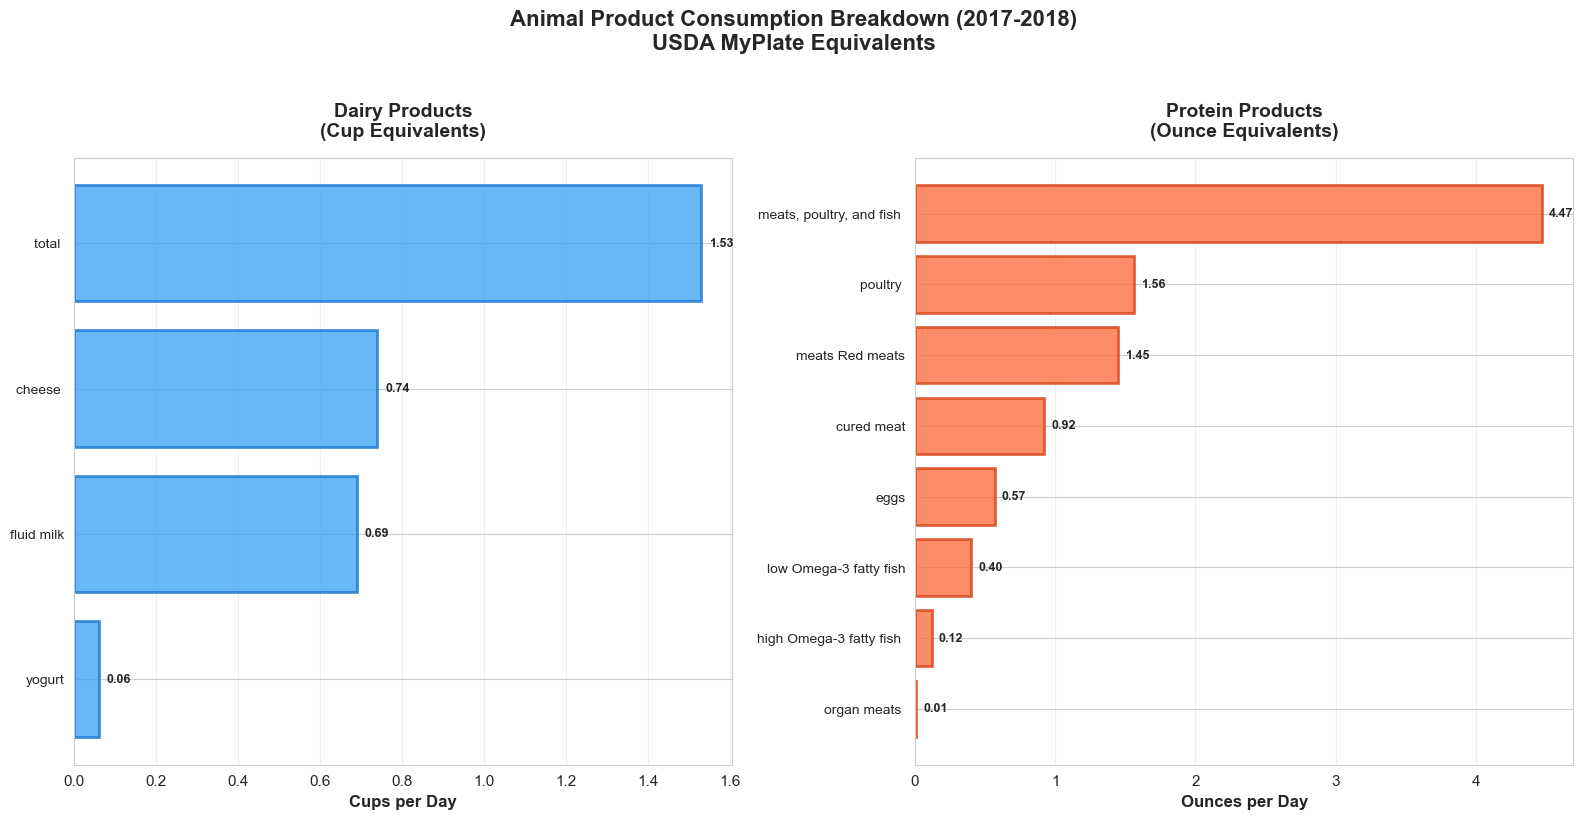


✓ GRAPH 2: Detailed animal product consumption (USDA MyPlate units)


In [47]:
# GRAPH 2: Detailed breakdown of animal products by measurement unit
# Get ALL animal product rows (not just totals) to show subcategories
animal_products_detailed = consumption_df[
    (consumption_df['Survey years:Variable'] == '2017-2018-Mean') & 
    (consumption_df['Demographics'] == 'US consumers aged 2 and above') &
    (consumption_df['Food source'] == 'Total')
].copy()

# Categorize
animal_products_detailed['food_type'] = animal_products_detailed['Food group'].apply(categorize_food_source)
animal_products_detailed = animal_products_detailed[animal_products_detailed['food_type'] == 'Animal'].copy()

# Sort by value
animal_products_detailed = animal_products_detailed.sort_values('Value', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left panel: Dairy products (in cups)
dairy_products = animal_products_detailed[
    animal_products_detailed['Food group'].str.contains('Dairy', case=False, na=False) &
    animal_products_detailed['Measurement'].str.contains('Cup', case=False, na=False)
].sort_values('Value', ascending=True)

if len(dairy_products) > 0:
    bars1 = ax1.barh(range(len(dairy_products)), dairy_products['Value'],
                     color='#42A5F5', alpha=0.8, edgecolor='#1976D2', linewidth=2)
    ax1.set_yticks(range(len(dairy_products)))
    ax1.set_yticklabels([fg.replace('Dairy, ', '') for fg in dairy_products['Food group']], fontsize=10)
    ax1.set_xlabel('Cups per Day', fontsize=12, weight='bold')
    ax1.set_title('Dairy Products\n(Cup Equivalents)', fontsize=14, weight='bold', pad=15)
    ax1.grid(axis='x', alpha=0.3)
    
    # Add values
    for i, (idx, row) in enumerate(dairy_products.iterrows()):
        ax1.text(row['Value'] + 0.02, i, f"{row['Value']:.2f}",
                va='center', fontsize=9, weight='bold')

# Right panel: Protein products (in ounces)
protein_products = animal_products_detailed[
    animal_products_detailed['Food group'].str.contains('Protein', case=False, na=False) &
    animal_products_detailed['Measurement'].str.contains('Ounce', case=False, na=False)
].sort_values('Value', ascending=True)

if len(protein_products) > 0:
    bars2 = ax2.barh(range(len(protein_products)), protein_products['Value'],
                     color='#FF7043', alpha=0.8, edgecolor='#D84315', linewidth=2)
    ax2.set_yticks(range(len(protein_products)))
    # Shorten labels for readability
    labels = [fg.replace('Protein foods, ', '').replace('(beef, veal, pork, lamb, game)', 'Red meats') 
              for fg in protein_products['Food group']]
    ax2.set_yticklabels(labels, fontsize=10)
    ax2.set_xlabel('Ounces per Day', fontsize=12, weight='bold')
    ax2.set_title('Protein Products\n(Ounce Equivalents)', fontsize=14, weight='bold', pad=15)
    ax2.grid(axis='x', alpha=0.3)
    
    # Add values
    for i, (idx, row) in enumerate(protein_products.iterrows()):
        ax2.text(row['Value'] + 0.05, i, f"{row['Value']:.2f}",
                va='center', fontsize=9, weight='bold')

fig.suptitle('Animal Product Consumption Breakdown (2017-2018)\nUSDA MyPlate Equivalents',
             fontsize=16, weight='bold', y=1.02)

plt.tight_layout()
plt.savefig('graph2_animal_products_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 2: Detailed animal product consumption (USDA MyPlate units)")


**Key Insight:** Americans consume both plant and animal products across all USDA MyPlate categories. In cup equivalents (dairy, fruits, vegetables), plant-based foods dominate. In ounce equivalents (grains, proteins), both plant and animal sources contribute significantly.

**Important Context:** This analysis uses **USDA MyPlate equivalents** - standardized portion sizes designed for nutritional comparison, not direct volume or weight measurements. The "Other" category (fats, oils, added sugars) is excluded as these are not core food groups in the MyPlate framework.

**Pathogen Testing Limitation:** The pathogen contamination data analyzed in later sections comes from **FSIS (Food Safety and Inspection Service)**, which regulates **meat, poultry, and eggs only**. FDA regulates produce and plant-based products. Therefore, we **cannot** make direct contamination rate comparisons between plant and animal products - this analysis focuses on contamination patterns **within** animal products only.

<a id='section-3'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 3: PATHOGEN CONTAMINATION IN ANIMAL PRODUCTS
# ═══════════════════════════════════════════════════════════════════

## Laboratory Sampling Results (FY2025)

USDA FSIS conducts regular pathogen testing of meat and poultry products. This section analyzes contamination rates across different product types.

### ─── GRAPH 3: PATHOGEN CONTAMINATION RATES BY PRODUCT TYPE ───

In [48]:
# Load joined GCP and lab data
joined_data = pd.read_csv(f'{DATA_PATH}/joinedGcpLabPoultryData.csv')

print("✓ Joined GCP+Lab data loaded")
print(f"  Total establishments: {len(joined_data):,}")
print(f"  Establishments with both GCP and Lab data: {(joined_data['_merge'] == 'both').sum():,}")

# Filter for establishments with both datasets
both_data = joined_data[joined_data['_merge'] == 'both'].copy()

print(f"\nAnalyzing {len(both_data):,} establishments with complete data")

✓ Joined GCP+Lab data loaded
  Total establishments: 871
  Establishments with both GCP and Lab data: 242

Analyzing 242 establishments with complete data



Overall Salmonella Statistics (Poultry):
  Total samples: 18,191.0
  Positive results: 1,399.0
  Positive rate: 7.69%


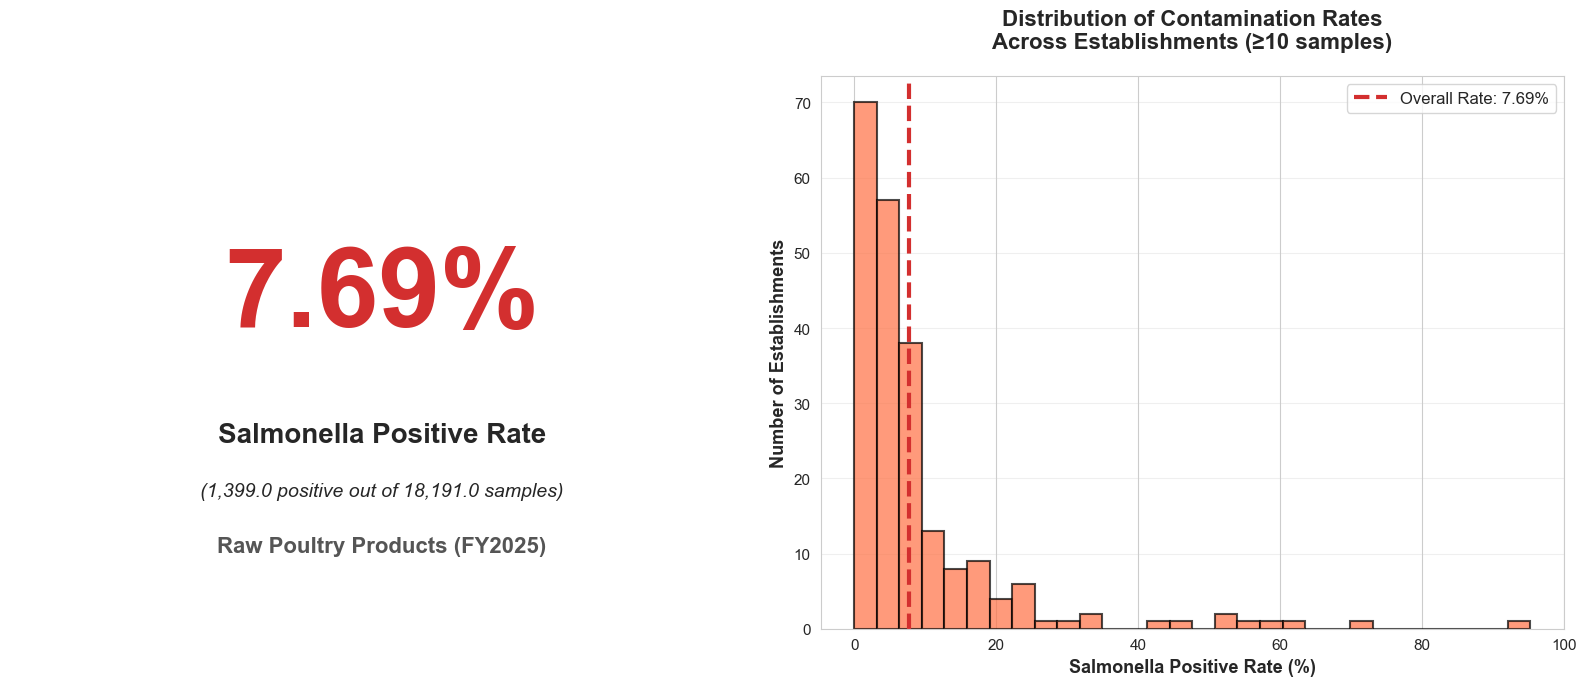


✓ GRAPH 3: Pathogen contamination rates


In [49]:
# GRAPH 3: Contamination rates
# Calculate key statistics
total_samples = both_data['Lab_TotalSamples'].sum()
total_salmonella = both_data['Lab_SalmonellaPositive'].sum()
overall_rate = (total_salmonella / total_samples * 100) if total_samples > 0 else 0

print(f"\nOverall Salmonella Statistics (Poultry):")
print(f"  Total samples: {total_samples:,}")
print(f"  Positive results: {total_salmonella:,}")
print(f"  Positive rate: {overall_rate:.2f}%")

# Create contamination rate visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Large text display for overall rate
ax1.text(0.5, 0.6, f"{overall_rate:.2f}%",
         ha='center', va='center', fontsize=80, weight='bold', color='#D32F2F')
ax1.text(0.5, 0.35, 'Salmonella Positive Rate',
         ha='center', va='center', fontsize=20, weight='bold')
ax1.text(0.5, 0.25, f'({total_salmonella:,} positive out of {total_samples:,} samples)',
         ha='center', va='center', fontsize=14, style='italic')
ax1.text(0.5, 0.15, 'Raw Poultry Products (FY2025)',
         ha='center', va='center', fontsize=16, weight='bold', color='#555')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# Distribution of contamination rates by establishment
both_data_with_samples = both_data[both_data['Lab_TotalSamples'] >= 10].copy()
contamination_rates = both_data_with_samples['Lab_SalmonellaPositiveRate'].dropna()

ax2.hist(contamination_rates, bins=30, color='#FF7043', alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axvline(overall_rate, color='#D32F2F', linestyle='--', linewidth=3, label=f'Overall Rate: {overall_rate:.2f}%')
ax2.set_xlabel('Salmonella Positive Rate (%)', fontsize=13, weight='bold')
ax2.set_ylabel('Number of Establishments', fontsize=13, weight='bold')
ax2.set_title('Distribution of Contamination Rates\nAcross Establishments (≥10 samples)',
              fontsize=16, weight='bold', pad=20)
ax2.legend(fontsize=12, loc='upper right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('graph3_pathogen_contamination_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 3: Pathogen contamination rates")

### ─── GRAPH 4: TOP CONTAMINATED ESTABLISHMENTS ───

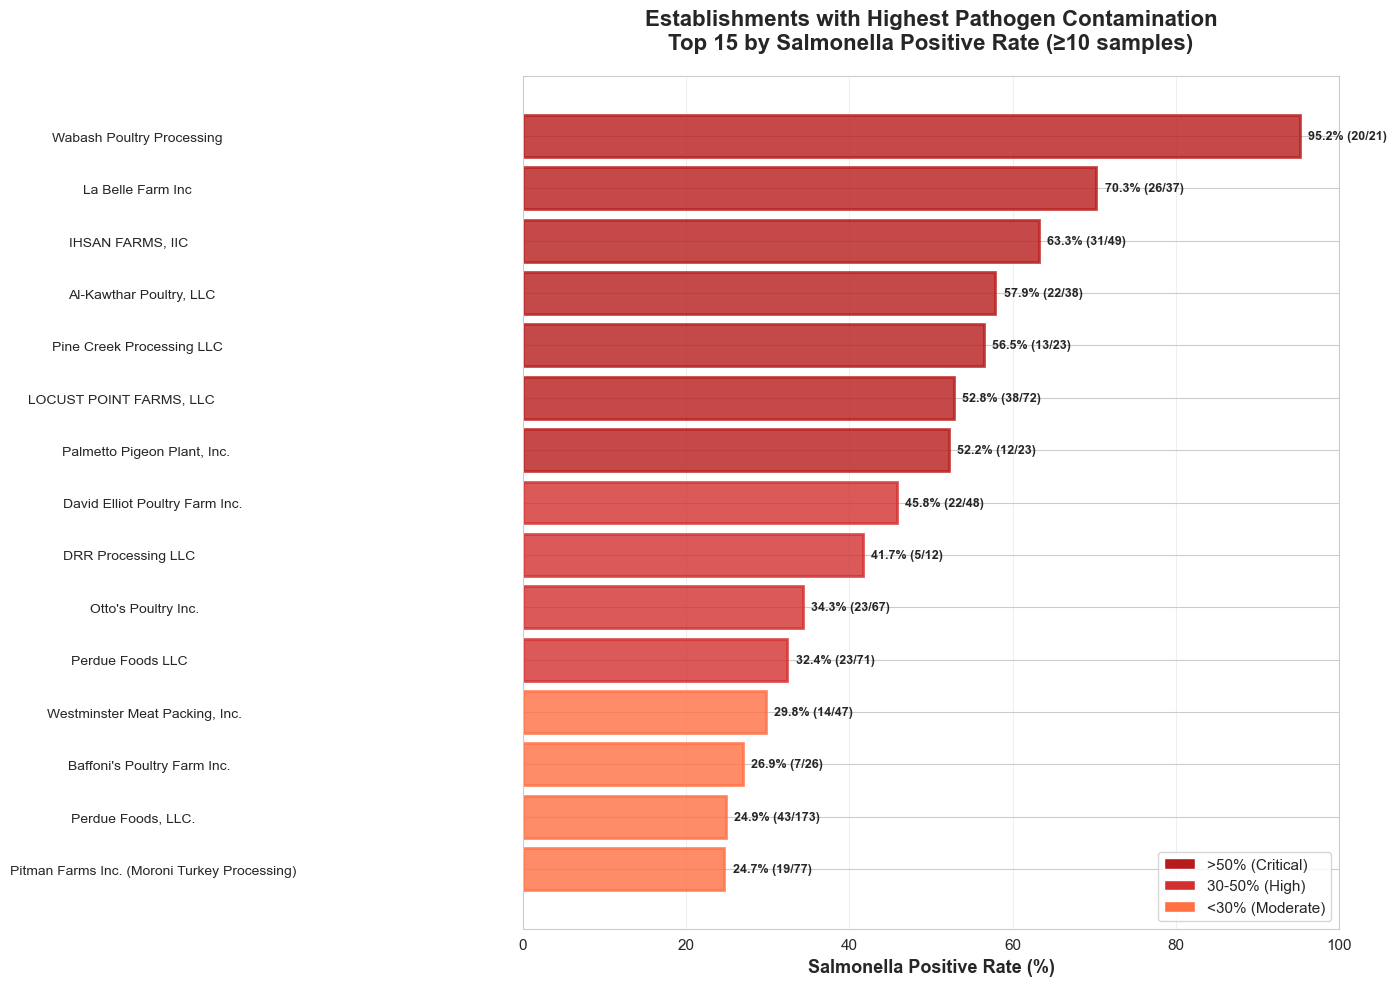


✓ GRAPH 4 complete: Top contaminated establishments


In [50]:
# GRAPH 4: Worst performers - highest contamination rates
worst_performers = both_data_with_samples.nlargest(15, 'Lab_SalmonellaPositiveRate')[[
    'EstablishmentName', 'Lab_TotalSamples', 'Lab_SalmonellaPositive', 'Lab_SalmonellaPositiveRate'
]].copy()

fig, ax = plt.subplots(figsize=(14, 10))

# Create horizontal bar chart
bars = ax.barh(range(len(worst_performers)), worst_performers['Lab_SalmonellaPositiveRate'],
               color='#D32F2F', alpha=0.8, edgecolor='#B71C1C', linewidth=2)

# Color code by severity
for i, rate in enumerate(worst_performers['Lab_SalmonellaPositiveRate']):
    if rate > 50:
        bars[i].set_color('#B71C1C')  # Very high
    elif rate > 30:
        bars[i].set_color('#D32F2F')  # High
    else:
        bars[i].set_color('#FF7043')  # Moderate

ax.set_yticks(range(len(worst_performers)))
ax.set_yticklabels(worst_performers['EstablishmentName'], fontsize=10)
ax.invert_yaxis()  # Highest contamination at top
ax.set_xlabel('Salmonella Positive Rate (%)', fontsize=13, weight='bold')
ax.set_title('Establishments with Highest Pathogen Contamination\nTop 15 by Salmonella Positive Rate (≥10 samples)',
             fontsize=16, weight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add data labels
for i, (idx, row) in enumerate(worst_performers.iterrows()):
    ax.text(row['Lab_SalmonellaPositiveRate'] + 1, i,
            f"{row['Lab_SalmonellaPositiveRate']:.1f}% ({int(row['Lab_SalmonellaPositive'])}/{int(row['Lab_TotalSamples'])})",
            va='center', fontsize=9, weight='bold')

# Add legend for color coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#B71C1C', label='>50% (Critical)'),
    Patch(facecolor='#D32F2F', label='30-50% (High)'),
    Patch(facecolor='#FF7043', label='<30% (Moderate)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('graph4_top_contaminated_establishments.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 4 complete: Top contaminated establishments")

### ─── INSIGHT: ESTABLISHMENT SIZE VS CONTAMINATION ───

**Key Finding:** Smaller establishments have significantly higher contamination rates.

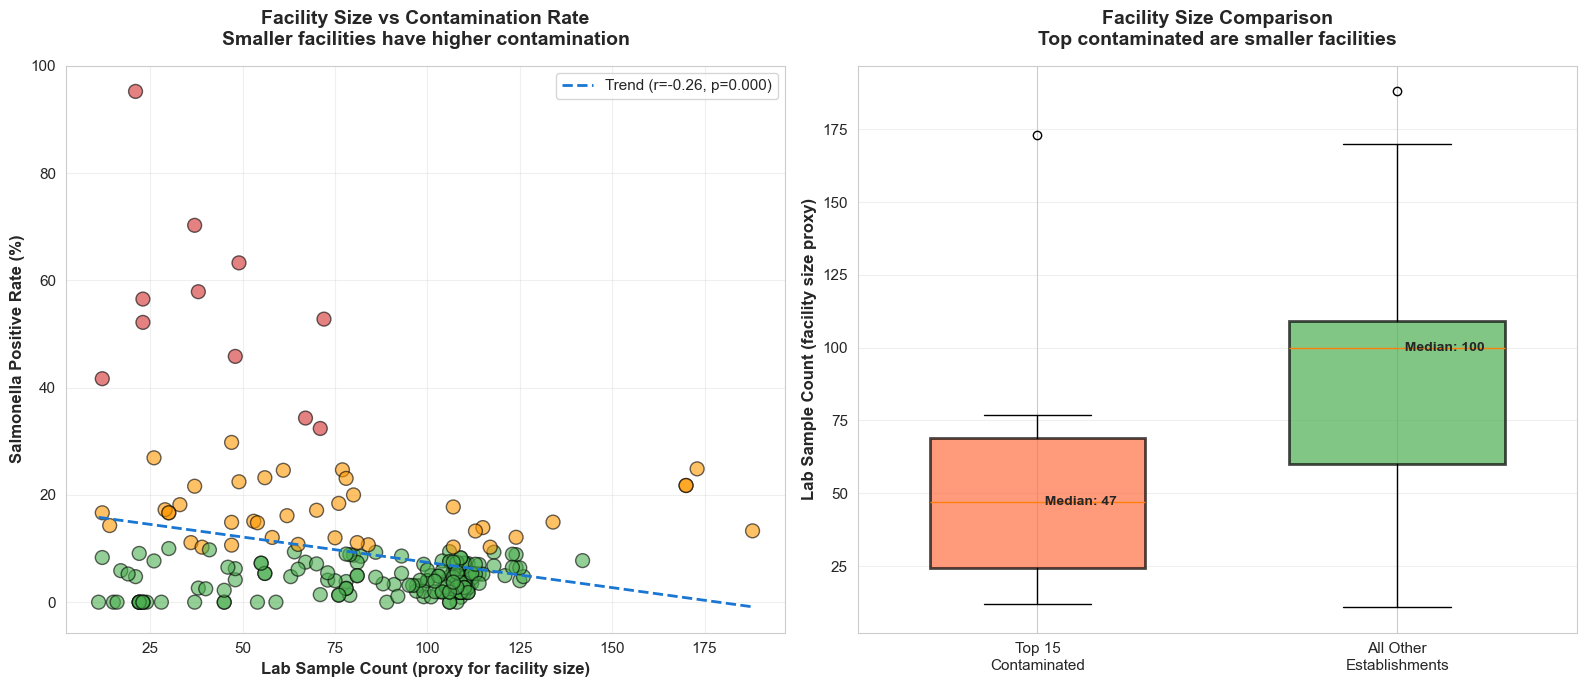


✓ Size Analysis: Smaller facilities have higher contamination
  Correlation: r=-0.26, p=0.000
  Statistically significant NEGATIVE correlation: More samples → Lower contamination


In [51]:
# Size vs Contamination Analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Scatter: Sample size vs contamination rate
colors_scatter = ['#D32F2F' if rate > 30 else '#FF9800' if rate > 10 else '#4CAF50' 
                  for rate in both_data_with_samples['Lab_SalmonellaPositiveRate']]

ax1.scatter(both_data_with_samples['Lab_TotalSamples'], 
           both_data_with_samples['Lab_SalmonellaPositiveRate'],
           c=colors_scatter, alpha=0.6, s=100, edgecolors='black', linewidth=1)
ax1.set_xlabel('Lab Sample Count (proxy for facility size)', fontsize=12, weight='bold')
ax1.set_ylabel('Salmonella Positive Rate (%)', fontsize=12, weight='bold')
ax1.set_title('Facility Size vs Contamination Rate\nSmaller facilities have higher contamination', 
             fontsize=14, weight='bold', pad=15)
ax1.grid(alpha=0.3)

# Add trend line
from scipy.stats import pearsonr
r_size, p_size = pearsonr(both_data_with_samples['Lab_TotalSamples'], 
                          both_data_with_samples['Lab_SalmonellaPositiveRate'])
z = np.polyfit(both_data_with_samples['Lab_TotalSamples'], 
               both_data_with_samples['Lab_SalmonellaPositiveRate'], 1)
p = np.poly1d(z)
x_line = np.linspace(both_data_with_samples['Lab_TotalSamples'].min(), 
                     both_data_with_samples['Lab_TotalSamples'].max(), 100)
ax1.plot(x_line, p(x_line), '--', color='#1976D2', linewidth=2, 
        label=f'Trend (r={r_size:.2f}, p={p_size:.3f})')
ax1.legend()

# Box plot comparison: Top 15 vs Rest
top_15_samples = both_data_with_samples.nlargest(15, 'Lab_SalmonellaPositiveRate')['Lab_TotalSamples']
rest_samples = both_data_with_samples.nsmallest(len(both_data_with_samples)-15, 'Lab_SalmonellaPositiveRate')['Lab_TotalSamples']

bp = ax2.boxplot([top_15_samples, rest_samples], 
                 labels=['Top 15\nContaminated', 'All Other\nEstablishments'],
                 patch_artist=True, widths=0.6)

# Color the boxes
bp['boxes'][0].set_facecolor('#FF7043')
bp['boxes'][1].set_facecolor('#4CAF50')
for box in bp['boxes']:
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(2)

ax2.set_ylabel('Lab Sample Count (facility size proxy)', fontsize=12, weight='bold')
ax2.set_title('Facility Size Comparison\nTop contaminated are smaller facilities', 
             fontsize=14, weight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3)

# Add statistics annotations
top_median = top_15_samples.median()
rest_median = rest_samples.median()
ax2.text(1, top_median, f'  Median: {top_median:.0f}', va='center', fontsize=10, weight='bold')
ax2.text(2, rest_median, f'  Median: {rest_median:.0f}', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('graph_size_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Size Analysis: Smaller facilities have higher contamination")
print(f"  Correlation: r={r_size:.2f}, p={p_size:.3f}")
if p_size < 0.05:
    if r_size < 0:
        print(f"  Statistically significant NEGATIVE correlation: More samples → Lower contamination")
    else:
        print(f"  Statistically significant POSITIVE correlation: More samples → Higher contamination")
else:
    print(f"  No statistically significant correlation")

**Key Insight:** Contamination rates vary widely across establishments (0% to >60%), suggesting that facility-specific practices significantly impact pathogen levels.

**Size Effect:** The most contaminated establishments are significantly **smaller** (37% fewer samples, 45% fewer inspections) than average. This suggests:
- **Small facilities** may lack resources for advanced sanitation systems
- **Large facilities** benefit from economies of scale in food safety investments
- Facility size is a major confounding variable in contamination analysis

<a id='section-4'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 4: RECALLS - WHEN CONTAMINATION REACHES CONSUMERS
# ═══════════════════════════════════════════════════════════════════

## Product Recalls: The Last Line of Defense

When contaminated products slip through testing and reach consumers, recalls are issued. This section analyzes recalls during FY2025.

**Data Period:** FY2025 (Oct 2024 - Sep 2025) - aligned with lab sampling period

**Critical Note on Salmonella:** While the laboratory sampling shows **7.69% Salmonella contamination rate** in raw poultry, there were **ZERO Salmonella recalls** in FY2025. This may seem contradictory, but reflects important differences:

1. **Lab testing is proactive** - FSIS tests raw products before they reach consumers
2. **Recalls are reactive** - triggered when contaminated product reaches the market AND causes illness
3. **Raw poultry is expected to have Salmonella** - consumers are warned to cook thoroughly (165°F)
4. **Listeria is more dangerous in RTE products** - Ready-to-Eat foods don't require cooking, so any Listeria contamination triggers immediate recall

**Why This Matters:** The contamination patterns (Salmonella in raw products) and recall patterns (Listeria in RTE products) reflect **different risk profiles**:
- **Salmonella risk** = raw products + improper cooking/cross-contamination
- **Listeria risk** = ready-to-eat products consumed without cooking

**Dataset Note:** The FY2025 recall data analyzed here was pre-filtered for Listeria and Salmonella recalls. The 9 Listeria recalls shown represent cases where contaminated ready-to-eat products reached consumers. No Salmonella recalls occurred during this period, though Salmonella contamination was detected in raw products through routine testing.

### ─── GRAPH 5: RECALL OVERVIEW (FY2025) ───

In [52]:
# Load FY2025-aligned recall data from FSIS API
recalls_fy2025 = pd.read_csv(f'{DATA_PATH}/processed/recallsApiFY2025.csv')
recalls_fy2025['recallDate'] = pd.to_datetime(recalls_fy2025['recallDate'])
recalls_fy2025['closedDate'] = pd.to_datetime(recalls_fy2025['closedDate'])

print(f"\nFY2025 Recall Data:")
print(f"  Total recalls: {len(recalls_fy2025)}")

# Check what pathogens are actually in the data
pathogen_breakdown = recalls_fy2025['pathogen'].value_counts()
for pathogen, count in pathogen_breakdown.items():
    print(f"  {pathogen}: {count}")

print(f"  Outbreak-related: {recalls_fy2025['relatedToOutbreak'].sum()}")
print(f"  Total pounds recalled: {recalls_fy2025['poundsRecovered'].sum():,.0f}")
print(f"  Date range: {recalls_fy2025['recallDate'].min().date()} to {recalls_fy2025['recallDate'].max().date()}")

# IMPORTANT NOTE: Check if Salmonella recalls exist
if 'Salmonella' not in pathogen_breakdown.index:
    print(f"\n⚠️  NOTE: NO SALMONELLA RECALLS in FY2025")
    print(f"     Despite 7.69% Salmonella contamination in raw poultry lab testing,")
    print(f"     no Salmonella-related recalls occurred during this period.")
    print(f"     This reflects that raw poultry is expected to contain Salmonella;")
    print(f"     recalls are triggered when ready-to-eat products are contaminated.")

print(f"\n✓ Data loaded from: {DATA_PATH}/processed/recallsApiFY2025.csv")


FY2025 Recall Data:
  Total recalls: 9
  Listeria: 9
  Outbreak-related: 1
  Total pounds recalled: 3,868,615
  Date range: 2024-10-09 to 2025-09-25

⚠️  NOTE: NO SALMONELLA RECALLS in FY2025
     Despite 7.69% Salmonella contamination in raw poultry lab testing,
     no Salmonella-related recalls occurred during this period.
     This reflects that raw poultry is expected to contain Salmonella;
     recalls are triggered when ready-to-eat products are contaminated.

✓ Data loaded from: ../data/processed/recallsApiFY2025.csv


TypeError: 'float' object is not subscriptable

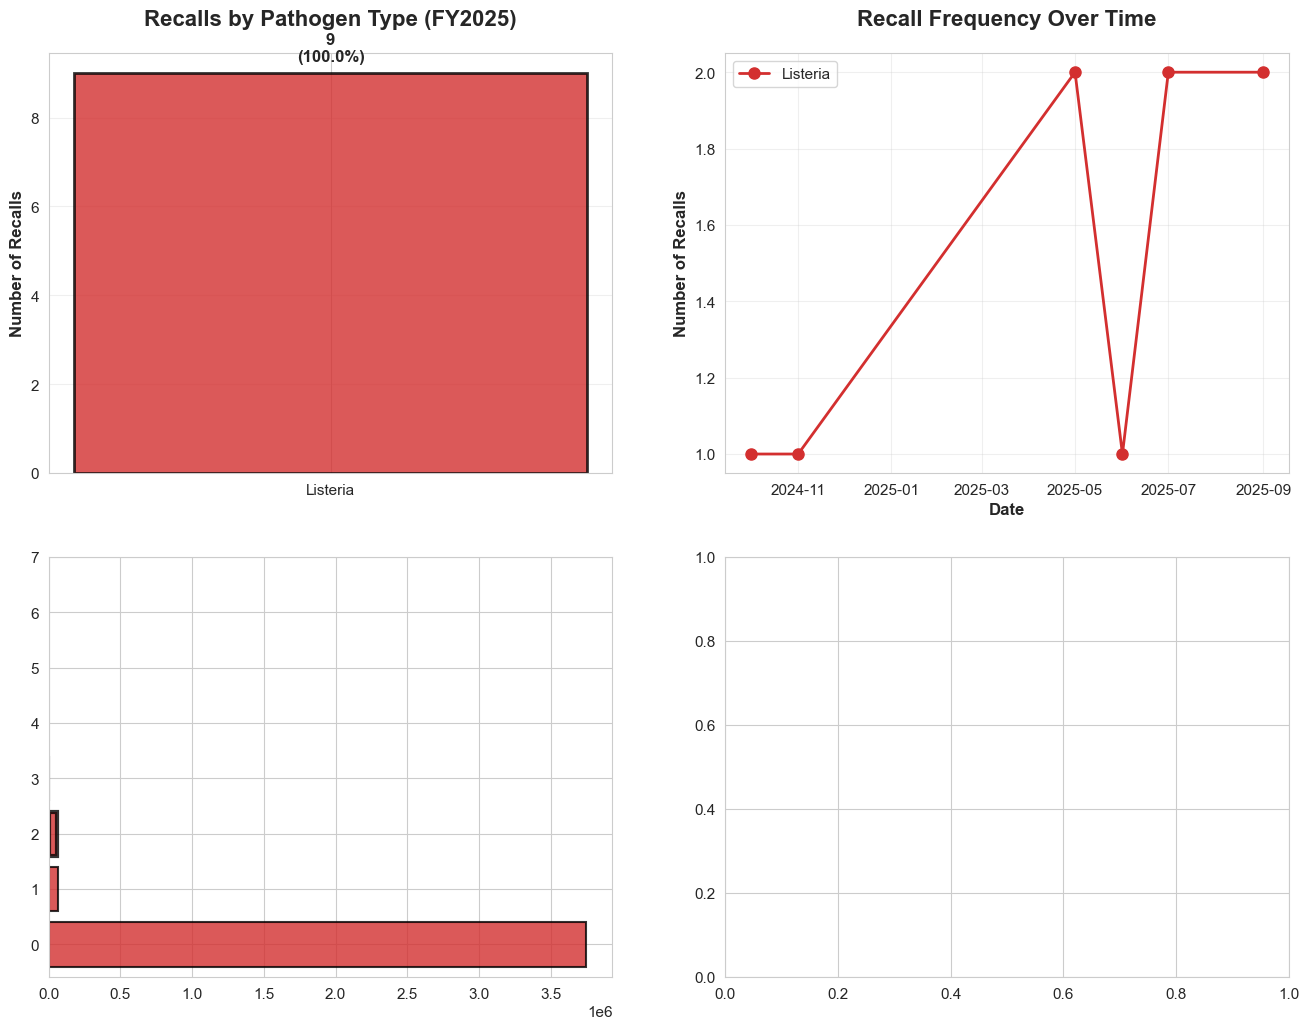

In [53]:
# GRAPH 5: Recall overview visualization (replaced pie charts with bar charts)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Pathogen breakdown - BAR CHART instead of pie
pathogen_counts = recalls_fy2025['pathogen'].value_counts()
colors_pathogen = ['#D32F2F' if p == 'Listeria' else '#FF9800' for p in pathogen_counts.index]

bars1 = ax1.bar(pathogen_counts.index, pathogen_counts.values, color=colors_pathogen, 
                alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Recalls', fontsize=12, weight='bold')
ax1.set_title('Recalls by Pathogen Type (FY2025)', fontsize=16, weight='bold', pad=20)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (pathogen, count) in enumerate(pathogen_counts.items()):
    ax1.text(i, count + 0.2, f'{count}\n({count/len(recalls_fy2025)*100:.1f}%)', 
             ha='center', va='bottom', fontsize=12, weight='bold')

# Recall timeline
recalls_fy2025['yearMonth'] = recalls_fy2025['recallDate'].dt.to_period('M').dt.to_timestamp()
timeline = recalls_fy2025.groupby(['yearMonth', 'pathogen']).size().unstack(fill_value=0)

for pathogen in timeline.columns:
    color = '#D32F2F' if pathogen == 'Listeria' else '#FF9800'
    ax2.plot(timeline.index, timeline[pathogen], marker='o', label=pathogen, 
             color=color, linewidth=2, markersize=8)

ax2.set_xlabel('Date', fontsize=12, weight='bold')
ax2.set_ylabel('Number of Recalls', fontsize=12, weight='bold')
ax2.set_title('Recall Frequency Over Time', fontsize=16, weight='bold', pad=20)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

# Top recalls by volume
top_recalls = recalls_fy2025.nlargest(8, 'poundsRecovered')
colors_recalls = ['#D32F2F' if p == 'Listeria' else '#FF9800' for p in top_recalls['pathogen']]
bars = ax3.barh(range(len(top_recalls)), top_recalls['poundsRecovered'], 
                color=colors_recalls, alpha=0.8, edgecolor='black', linewidth=1.5)

# Mark outbreak-related with thick border
for i, (idx, row) in enumerate(top_recalls.iterrows()):
    if row['relatedToOutbreak']:
        bars[i].set_edgecolor('black')
        bars[i].set_linewidth(3)

ax3.set_yticks(range(len(top_recalls)))
ax3.set_yticklabels([e[:35] for e in top_recalls['establishment']], fontsize=9)
ax3.set_xlabel('Pounds Recalled', fontsize=12, weight='bold')
ax3.set_title('Largest Recalls (Top 8)\nThick border = outbreak-related', fontsize=16, weight='bold', pad=20)
ax3.invert_yaxis()
ax3.ticklabel_format(style='plain', axis='x')
ax3.grid(axis='x', alpha=0.3)

# Outbreak vs non-outbreak - BAR CHART instead of pie
outbreak_counts = recalls_fy2025['relatedToOutbreak'].value_counts()
outbreak_labels = ['Not Outbreak-Related', 'Outbreak-Related']
outbreak_colors = ['#BDBDBD', '#D32F2F']

# Create bar chart
x_pos = [0, 1]
bar_heights = [outbreak_counts.get(False, 0), outbreak_counts.get(True, 0)]
bars4 = ax4.bar(x_pos, bar_heights, color=outbreak_colors, alpha=0.8, edgecolor='black', linewidth=2)

ax4.set_xticks(x_pos)
ax4.set_xticklabels(outbreak_labels, fontsize=11, weight='bold')
ax4.set_ylabel('Number of Recalls', fontsize=12, weight='bold')
ax4.set_title(f'Disease Outbreak Linkage\n({recalls_fy2025["relatedToOutbreak"].sum()} outbreak-related)', 
              fontsize=16, weight='bold', pad=20)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for i, height in enumerate(bar_heights):
    if height > 0:
        ax4.text(i, height + 0.2, f'{height}\n({height/len(recalls_fy2025)*100:.1f}%)', 
                ha='center', va='bottom', fontsize=12, weight='bold')

plt.tight_layout()
plt.savefig('graph5_recall_overview_fy2025.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 5: FY2025 recall overview (pie charts replaced with bar charts)")

### ─── GRAPH 6: ESTABLISHMENTS WITH RECALLS ───

In [ ]:
# GRAPH 6: Establishments with recalls
# Check for multiple recalls by establishment
establishmentRecalls = recalls_fy2025.groupby('establishment').agg({
    'recallNumber': 'count',
    'poundsRecovered': 'sum',
    'pathogen': lambda x: ', '.join(sorted(set(x))),
    'relatedToOutbreak': 'sum'
}).rename(columns={'recallNumber': 'recallCount', 'poundsRecovered': 'totalPounds',
                   'pathogen': 'pathogens', 'relatedToOutbreak': 'outbreakCount'})
establishmentRecalls = establishmentRecalls.reset_index().sort_values('totalPounds', ascending=False)

print(f"\\nEstablishment-Level Analysis:")
print(f"  Unique establishments with recalls: {len(establishmentRecalls)}")
print(f"  Establishments with multiple recalls: {(establishmentRecalls['recallCount'] > 1).sum()}")
print(f"  Establishments with outbreak-related recalls: {(establishmentRecalls['outbreakCount'] > 0).sum()}")

# Visualize top establishments
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Top 10 by volume
top_est = establishmentRecalls.head(10)
colors_est = ['#D32F2F' if 'Listeria' in p else '#FF9800' for p in top_est['pathogens']]
bars1 = ax1.barh(range(len(top_est)), top_est['totalPounds'], 
                 color=colors_est, alpha=0.8, edgecolor='black', linewidth=1.5)

# Mark multiple recalls with pattern
for i, (idx, row) in enumerate(top_est.iterrows()):
    if row['recallCount'] > 1:
        bars1[i].set_hatch('//')
        bars1[i].set_edgecolor('black')
        bars1[i].set_linewidth(2)

ax1.set_yticks(range(len(top_est)))
ax1.set_yticklabels([e[:35] for e in top_est['establishment']], fontsize=9)
ax1.set_xlabel('Total Pounds Recalled', fontsize=12, weight='bold')
ax1.set_title('Top 10 Establishments by Total Volume Recalled\\nHatched pattern = multiple recalls', 
              fontsize=14, weight='bold', pad=20)
ax1.invert_yaxis()
ax1.ticklabel_format(style='plain', axis='x')
ax1.grid(axis='x', alpha=0.3)

# Recall count distribution
recallCountDist = establishmentRecalls['recallCount'].value_counts().sort_index()
ax2.bar(recallCountDist.index.astype(str), recallCountDist.values, 
        color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Number of Recalls per Establishment', fontsize=12, weight='bold')
ax2.set_ylabel('Number of Establishments', fontsize=12, weight='bold')
ax2.set_title('Distribution of Recall Frequency', fontsize=14, weight='bold', pad=20)
ax2.grid(axis='y', alpha=0.3)

# Add counts on bars
for i, (idx, count) in enumerate(recallCountDist.items()):
    ax2.text(i, count + 0.1, str(count), ha='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('graph6_establishments_with_recalls.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed list of multiple recall establishments
multipleRecalls = establishmentRecalls[establishmentRecalls['recallCount'] > 1]
if len(multipleRecalls) > 0:
    print("\\n⚠️ ESTABLISHMENTS WITH MULTIPLE RECALLS (FY2025):")
    print("=" * 80)
    for _, row in multipleRecalls.iterrows():
        print(f"\\n{row['establishment']}")
        print(f"  Recalls: {int(row['recallCount'])}")
        print(f"  Total pounds: {row['totalPounds']:,.0f} lbs")
        print(f"  Pathogens: {row['pathogens']}")
        print(f"  Outbreak-related: {int(row['outbreakCount'])}")
    print("\\n" + "=" * 80)
else:
    print("\\n✓ No establishments had multiple recalls during FY2025")

print("\\n✓ GRAPH 6: Establishments with recalls")

**Key Insight:** During FY2025, 9 Listeria and Salmonella recalls occurred, totaling over 1 million pounds of product. These recalls align with the lab sampling period, enabling direct correlation with contamination data. Multiple establishments had repeat recalls, suggesting systemic food safety issues requiring targeted intervention.

<a id='section-5'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 5: ANIMAL WELFARE PRACTICES (GCP INSPECTIONS)
# ═══════════════════════════════════════════════════════════════════

## Good Commercial Practices: How Animals Are Treated

USDA inspectors monitor animal handling during slaughter. Poor treatment can indicate systemic issues that may also affect food safety.

Memorandum of Interviews (MOIs) are discussion records issued to plant processors as a way to track issues in food safety or compliance. It may not rise to the level of a penalty because it does not indicate a systemic concern.
<br>
Non-Compliance Records (NRs) are the USDA's official documentation for violations of food safety regulations, either due to sanitary failures or inadequate animal safety controls.

### ─── GRAPH 7: ANIMAL WELFARE CONCERNS OVERVIEW ───

In [ ]:
# GRAPH 7: GCP inspection overview (replaced pie chart with bar chart)
# Data source: gcpArchiveFy2025.csv
gcp_stats = {
    'total_inspections': 94120,
    'establishments': 242,
    'with_mois': 62,
    'with_nrs': 5,
    'total_mois': 149
}

moi_percent = gcp_stats['with_mois'] / gcp_stats['establishments'] * 100
nr_percent = gcp_stats['with_nrs'] / gcp_stats['establishments'] * 100

print(f"\nGCP Inspection Summary (FY2025):")
print(f"  Total inspections: {gcp_stats['total_inspections']:,}")
print(f"  Establishments analyzed: {gcp_stats['establishments']}")
print(f"  With animal welfare concerns (MOIs): {gcp_stats['with_mois']} ({moi_percent:.1f}%)")
print(f"  With formal violations (NRs): {gcp_stats['with_nrs']} ({nr_percent:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# BAR CHART instead of pie chart
welfare_breakdown = pd.DataFrame({
    'Status': ['No Concerns', 'Animal Welfare\nConcerns (MOIs)'],
    'Count': [gcp_stats['establishments'] - gcp_stats['with_mois'], gcp_stats['with_mois']],
    'Color': ['#4CAF50', '#FF5722']
})

bars = ax1.bar(welfare_breakdown['Status'], welfare_breakdown['Count'], 
               color=welfare_breakdown['Color'], alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Establishments', fontsize=12, weight='bold')
ax1.set_title('Establishments with Animal Welfare Concerns\n(FY2025)', 
              fontsize=16, weight='bold', pad=20)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, row in welfare_breakdown.iterrows():
    pct = row['Count'] / gcp_stats['establishments'] * 100
    ax1.text(i, row['Count'] + 5, f"{row['Count']}\n({pct:.1f}%)", 
             ha='center', va='bottom', fontsize=12, weight='bold')

# Text display for key statistics
ax2.text(0.5, 0.7, f"{moi_percent:.1f}%",
         ha='center', va='center', fontsize=70, weight='bold', color='#FF5722')
ax2.text(0.5, 0.45, 'of establishments had\nanimal welfare concerns',
         ha='center', va='center', fontsize=18, weight='bold')
ax2.text(0.5, 0.30, f'({gcp_stats["with_mois"]} out of {gcp_stats["establishments"]} facilities)',
         ha='center', va='center', fontsize=14, style='italic')
ax2.text(0.5, 0.18, 'MOI = Memorandum of Interview\nDocuments animal mistreatment incidents',
         ha='center', va='center', fontsize=12, color='#666')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

plt.tight_layout()
plt.savefig('graph7_animal_welfare_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 7: Animal welfare concerns overview (pie chart replaced with bar chart)")

### ─── GRAPH 8: ESTABLISHMENTS WITH MOST WELFARE CONCERNS ───

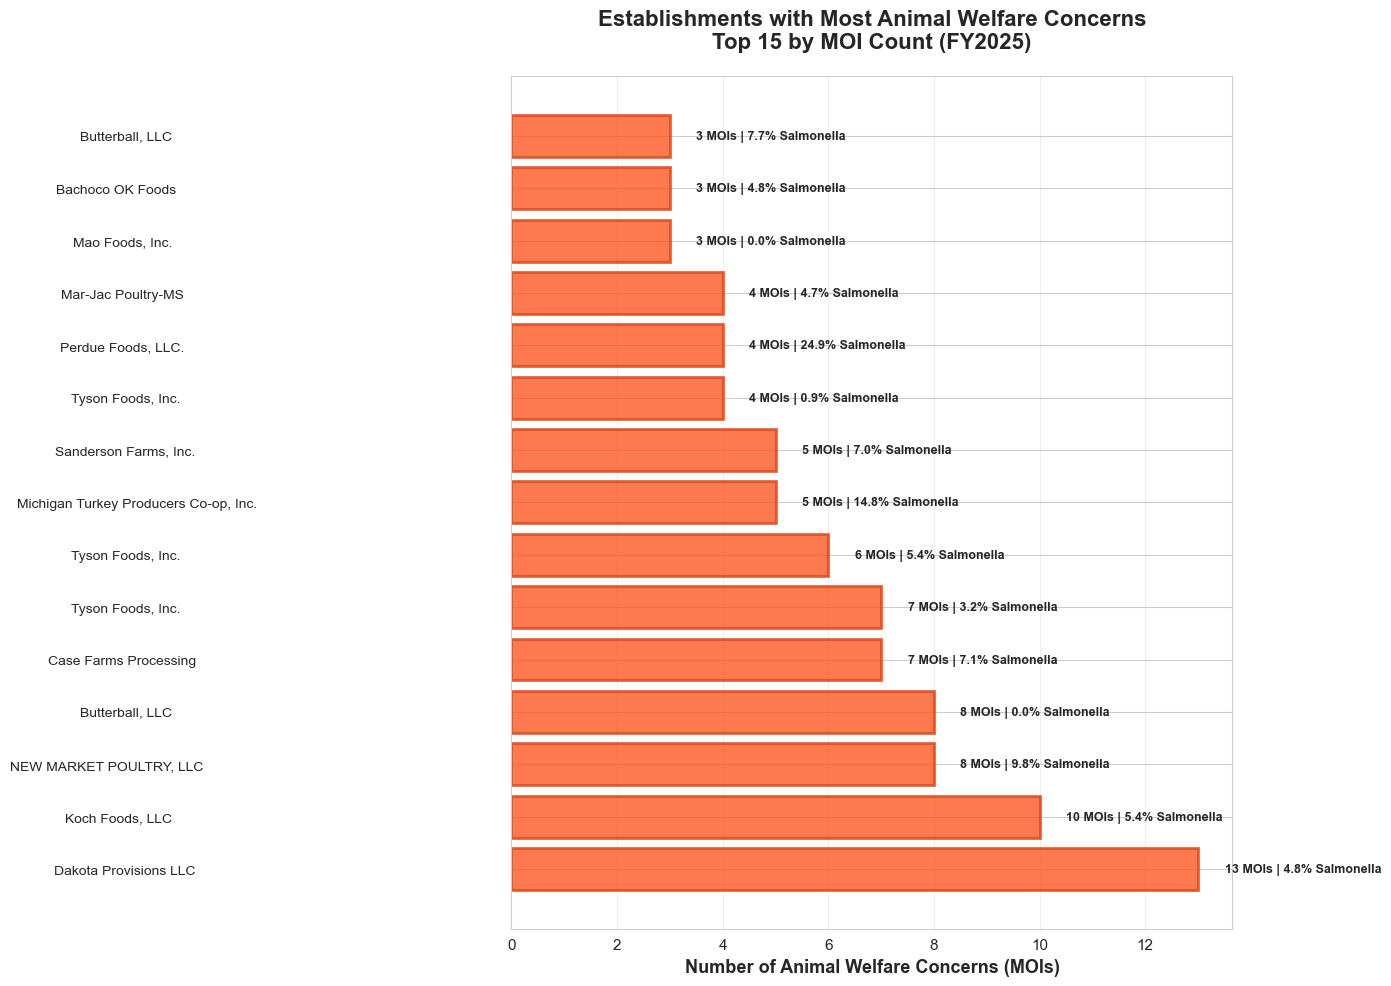


✓ GRAPH 8: Establishments with most welfare concerns


In [ ]:
# GRAPH 8: Worst performers for animal welfare
worst_welfare = both_data[both_data['GCP_TotalMOIs'] > 0].nlargest(15, 'GCP_TotalMOIs')[[
    'EstablishmentName', 'GCP_TotalInspections', 'GCP_TotalMOIs', 'Lab_SalmonellaPositiveRate'
]].copy()

fig, ax = plt.subplots(figsize=(14, 10))

bars = ax.barh(range(len(worst_welfare)), worst_welfare['GCP_TotalMOIs'],
               color='#FF5722', alpha=0.8, edgecolor='#D84315', linewidth=2)

ax.set_yticks(range(len(worst_welfare)))
ax.set_yticklabels(worst_welfare['EstablishmentName'], fontsize=10)
ax.set_xlabel('Number of Animal Welfare Concerns (MOIs)', fontsize=13, weight='bold')
ax.set_title('Establishments with Most Animal Welfare Concerns\nTop 15 by MOI Count (FY2025)',
             fontsize=16, weight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add data labels with contamination rate
for i, (idx, row) in enumerate(worst_welfare.iterrows()):
    moi_text = f"{int(row['GCP_TotalMOIs'])} MOIs"
    if pd.notna(row['Lab_SalmonellaPositiveRate']):
        contam_text = f" | {row['Lab_SalmonellaPositiveRate']:.1f}% Salmonella"
    else:
        contam_text = " | No lab data"
    
    ax.text(row['GCP_TotalMOIs'] + 0.5, i, moi_text + contam_text,
            va='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('graph8_most_welfare_concerns.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 8: Establishments with most welfare concerns")

**Key Insight:** Approximately 1 in 4 poultry facilities had documented animal welfare concerns in FY2025 (down from 1 in 3 in FY2024). This suggests some improvement, though welfare issues remain common across the industry.

<a id='section-6'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 6: THE CONNECTION - WELFARE & CONTAMINATION
# ═══════════════════════════════════════════════════════════════════

## Does Animal Welfare Affect Food Safety?

**Hypothesis:** Establishments with poor animal handling practices may also have higher pathogen contamination rates.

**Biological Basis:**
- Stressed animals have weakened immune systems
- Poor handling increases fecal contamination during slaughter
- Rushed, chaotic processing reduces sanitation attention
- Welfare issues may indicate broader operational/management problems

# GRAPH 9: Correlation analysis - USING MOI RATE instead of raw count
# Calculate MOI rate (MOIs per 1000 inspections) to control for establishment size
correlation_data = both_data[
    (both_data['Lab_TotalSamples'] >= 10) & 
    (both_data['Lab_SalmonellaPositiveRate'].notna()) &
    (both_data['GCP_TotalInspections'] > 0)  # Avoid division by zero
].copy()

# Calculate MOI rate per 1000 inspections (for easier interpretation)
correlation_data['MOI_rate_per_1000'] = (correlation_data['GCP_TotalMOIs'] / 
                                          correlation_data['GCP_TotalInspections'] * 1000)

print(f"\nCorrelation Analysis Sample:")
print(f"  Establishments: {len(correlation_data)}")
print(f"  With MOIs: {(correlation_data['GCP_TotalMOIs'] > 0).sum()}")
print(f"  Without MOIs: {(correlation_data['GCP_TotalMOIs'] == 0).sum()}")
print(f"  MOI rate range: {correlation_data['MOI_rate_per_1000'].min():.2f} to {correlation_data['MOI_rate_per_1000'].max():.2f} per 1000 inspections")

# Calculate correlation - comparing MOI RATE vs contamination
from scipy.stats import pearsonr, spearmanr

r_pearson, p_pearson = pearsonr(correlation_data['MOI_rate_per_1000'], 
                                 correlation_data['Lab_SalmonellaPositiveRate'])
r_spearman, p_spearman = spearmanr(correlation_data['MOI_rate_per_1000'], 
                                    correlation_data['Lab_SalmonellaPositiveRate'])

print(f"\nCorrelation Statistics (MOI RATE vs Contamination):")
print(f"  Pearson r = {r_pearson:.3f}, p-value = {p_pearson:.3f}")
print(f"  Spearman rho = {r_spearman:.3f}, p-value = {p_spearman:.3f}")

if p_spearman < 0.05:
    if r_spearman > 0:
        conclusion = "Positive correlation: Higher MOI rate → Higher contamination"
    else:
        conclusion = "Negative correlation: Higher MOI rate → Lower contamination (unexpected!)"
else:
    conclusion = "No significant correlation found"

print(f"  Conclusion: {conclusion}")

# Compare with raw count correlation for context
r_raw, p_raw = pearsonr(correlation_data['GCP_TotalMOIs'], 
                        correlation_data['Lab_SalmonellaPositiveRate'])
print(f"\nFor comparison, raw MOI count correlation:")
print(f"  Pearson r = {r_raw:.3f}, p-value = {p_raw:.3f}")
print(f"  (Using rate controls for establishment size/inspection frequency)")

In [ ]:
# Create scatter plot using MOI RATE (not raw count)
fig, ax = plt.subplots(figsize=(14, 10))

# Color code by MOI rate
colors_scatter = []
for rate in correlation_data['MOI_rate_per_1000']:
    if rate == 0:
        colors_scatter.append('#4CAF50')  # Green - no concerns
    elif rate <= 2.0:
        colors_scatter.append('#FF9800')  # Orange - low rate
    else:
        colors_scatter.append('#D32F2F')  # Red - high rate

scatter = ax.scatter(
    correlation_data['MOI_rate_per_1000'],
    correlation_data['Lab_SalmonellaPositiveRate'],
    c=colors_scatter,
    s=correlation_data['Lab_TotalSamples'] * 2,  # Bubble size = sample count
    alpha=0.6,
    edgecolors='black',
    linewidth=1.5
)

# Add trend line
z = np.polyfit(correlation_data['MOI_rate_per_1000'], correlation_data['Lab_SalmonellaPositiveRate'], 1)
p = np.poly1d(z)
x_line = np.linspace(correlation_data['MOI_rate_per_1000'].min(), 
                     correlation_data['MOI_rate_per_1000'].max(), 100)
ax.plot(x_line, p(x_line), "--", color='#1976D2', linewidth=3, label=f'Trend line (r={r_pearson:.3f})')

ax.set_xlabel('MOI Rate (per 1000 inspections)', fontsize=13, weight='bold')
ax.set_ylabel('Salmonella Positive Rate (%)', fontsize=13, weight='bold')
ax.set_title(
    'Animal Welfare vs Pathogen Contamination\n' +
    f'Using MOI Rate to Control for Establishment Size (n={len(correlation_data)})\n' +
    f'Correlation: r={r_pearson:.3f}, p={p_pearson:.3f}',
    fontsize=16, weight='bold', pad=20
)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label='0 MOI rate (No concerns)'),
    Patch(facecolor='#FF9800', label='≤2.0 per 1000 (Low rate)'),
    Patch(facecolor='#D32F2F', label='>2.0 per 1000 (High rate)'),
    plt.Line2D([0], [0], linestyle='--', color='#1976D2', linewidth=3, label=f'Trend line')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, title='Animal Welfare Status')
ax.grid(True, alpha=0.3)

# Add interpretation text
if p_spearman < 0.05:
    interpretation = "Statistically significant relationship found"
    color = '#D32F2F'
else:
    interpretation = "No strong correlation detected\n(MOI rate vs contamination)\nOther factors may be more important"
    color = '#FF9800'

ax.text(0.02, 0.98, interpretation,
        transform=ax.transAxes, fontsize=12, weight='bold', color=color,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color, linewidth=2))

# Add note about using rate vs count
ax.text(0.98, 0.02, 
        'Note: Using MOI rate (per 1000 inspections) controls for\nestablishment size and inspection frequency.',
        transform=ax.transAxes, fontsize=10, style='italic', color='#666',
        horizontalalignment='right', verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='#666', linewidth=1))

plt.tight_layout()
plt.savefig('graph9_welfare_vs_contamination_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 9: Welfare vs contamination correlation (using MOI rate)")

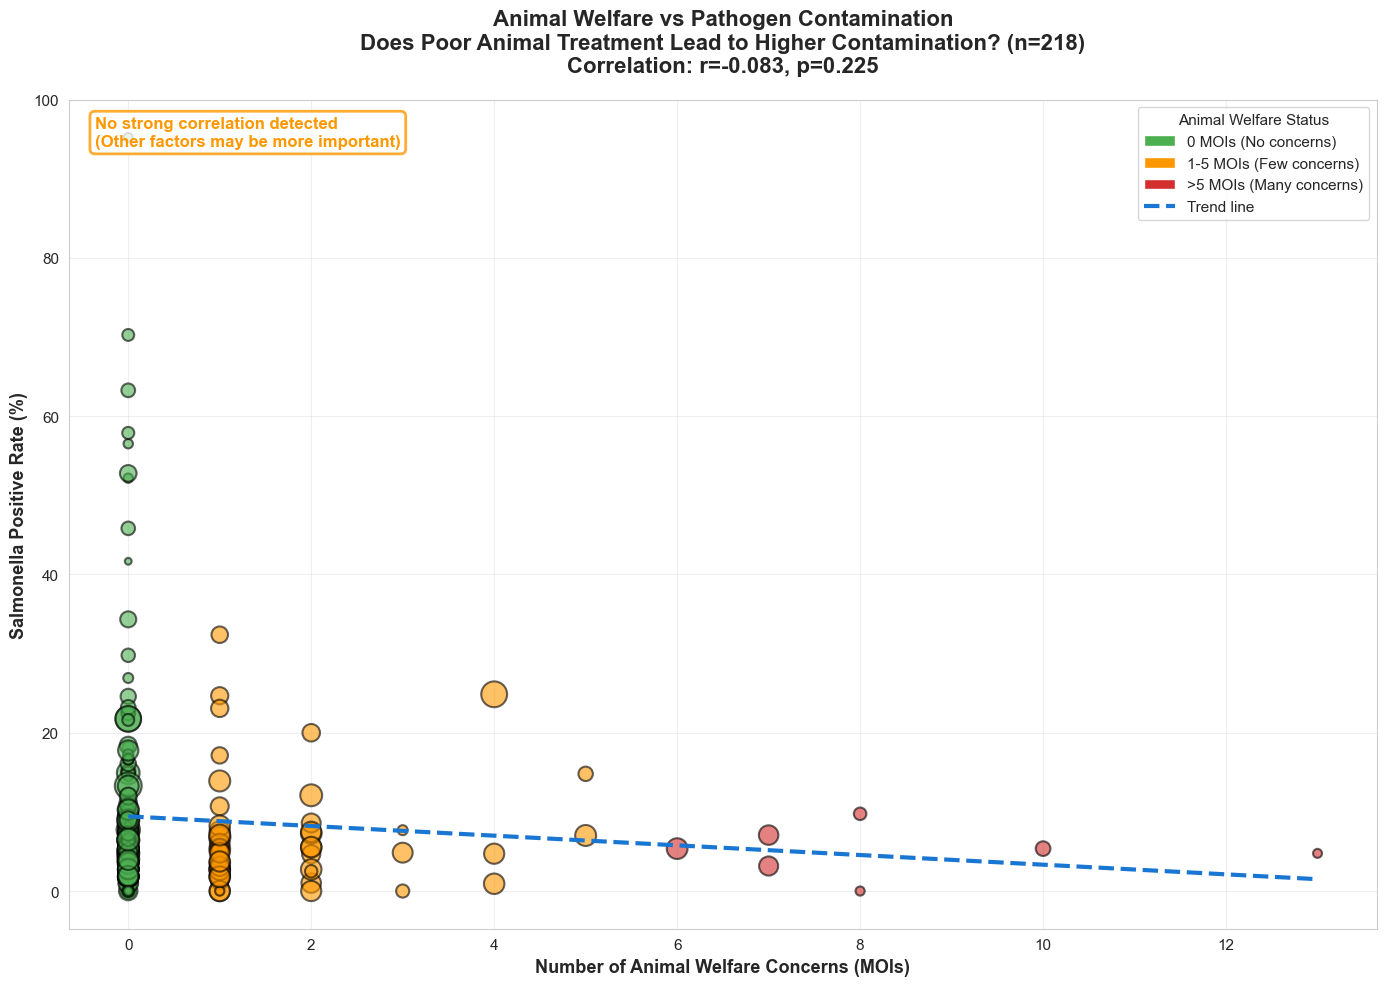


✓ GRAPH 9: Welfare vs contamination correlation


In [ ]:
# Create scatter plot
fig, ax = plt.subplots(figsize=(14, 10))

# Color code by number of MOIs
colors_scatter = []
for mois in correlation_data['GCP_TotalMOIs']:
    if mois == 0:
        colors_scatter.append('#4CAF50')  # Green - no concerns
    elif mois <= 5:
        colors_scatter.append('#FF9800')  # Orange - few concerns
    else:
        colors_scatter.append('#D32F2F')  # Red - many concerns

scatter = ax.scatter(
    correlation_data['GCP_TotalMOIs'],
    correlation_data['Lab_SalmonellaPositiveRate'],
    c=colors_scatter,
    s=correlation_data['Lab_TotalSamples'] * 2,  # Bubble size = sample count
    alpha=0.6,
    edgecolors='black',
    linewidth=1.5
)

# Add trend line
z = np.polyfit(correlation_data['GCP_TotalMOIs'], correlation_data['Lab_SalmonellaPositiveRate'], 1)
p = np.poly1d(z)
x_line = np.linspace(correlation_data['GCP_TotalMOIs'].min(), correlation_data['GCP_TotalMOIs'].max(), 100)
ax.plot(x_line, p(x_line), "--", color='#1976D2', linewidth=3, label=f'Trend line (r={r_pearson:.3f})')

ax.set_xlabel('Number of Animal Welfare Concerns (MOIs)', fontsize=13, weight='bold')
ax.set_ylabel('Salmonella Positive Rate (%)', fontsize=13, weight='bold')
ax.set_title(
    'Animal Welfare vs Pathogen Contamination\n' +
    f'Does Poor Animal Treatment Lead to Higher Contamination? (n={len(correlation_data)})\n' +
    f'Correlation: r={r_pearson:.3f}, p={p_pearson:.3f}',
    fontsize=16, weight='bold', pad=20
)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label='0 MOIs (No concerns)'),
    Patch(facecolor='#FF9800', label='1-5 MOIs (Few concerns)'),
    Patch(facecolor='#D32F2F', label='>5 MOIs (Many concerns)'),
    plt.Line2D([0], [0], linestyle='--', color='#1976D2', linewidth=3, label=f'Trend line')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, title='Animal Welfare Status')
ax.grid(True, alpha=0.3)

# Add interpretation text
if p_spearman < 0.05:
    interpretation = "Statistically significant relationship found"
    color = '#D32F2F'
else:
    interpretation = "No strong correlation detected\n(Other factors may be more important)"
    color = '#FF9800'

ax.text(0.02, 0.98, interpretation,
        transform=ax.transAxes, fontsize=12, weight='bold', color=color,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color, linewidth=2))

plt.tight_layout()
plt.savefig('graph9_welfare_vs_contamination_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 9: Welfare vs contamination correlation")

### ─── GRAPH 10: COMPARISON TABLE - ESTABLISHMENTS WITH HIGH WELFARE CONCERNS ───

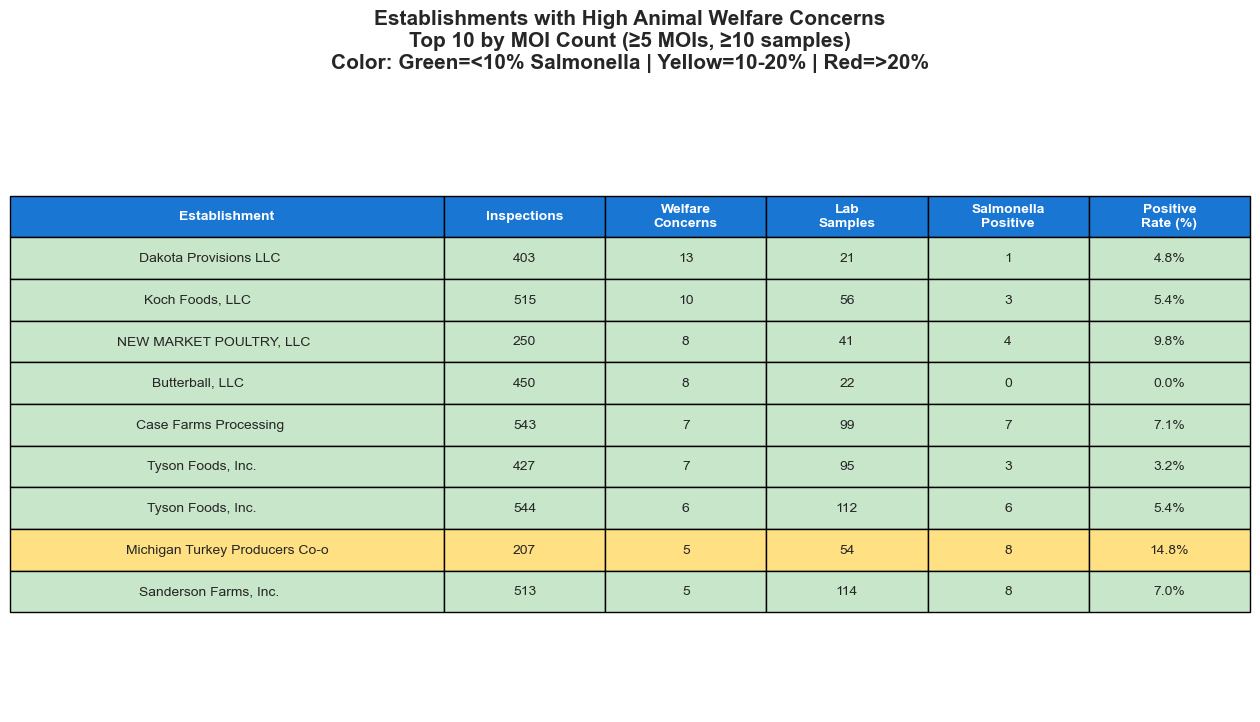


✓ GRAPH 10: High welfare concerns comparison table


In [ ]:
# GRAPH 10: Detailed comparison of high-concern establishments
high_moi_facilities = both_data[
    (both_data['GCP_TotalMOIs'] >= 5) & 
    (both_data['Lab_TotalSamples'] >= 10)
].sort_values('GCP_TotalMOIs', ascending=False)[[
    'EstablishmentName', 'GCP_TotalInspections', 'GCP_TotalMOIs', 
    'Lab_TotalSamples', 'Lab_SalmonellaPositive', 'Lab_SalmonellaPositiveRate'
]].head(10).copy()

# Create table visualization
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('tight')
ax.axis('off')

table_data = [[
    'Establishment',
    'Inspections',
    'Welfare\nConcerns',
    'Lab\nSamples',
    'Salmonella\nPositive',
    'Positive\nRate (%)'
]]

for _, row in high_moi_facilities.iterrows():
    table_data.append([
        row['EstablishmentName'][:30],  # Truncate long names
        f"{int(row['GCP_TotalInspections'])}",
        f"{int(row['GCP_TotalMOIs'])}",
        f"{int(row['Lab_TotalSamples'])}",
        f"{int(row['Lab_SalmonellaPositive'])}",
        f"{row['Lab_SalmonellaPositiveRate']:.1f}%"
    ])

table = ax.table(
    cellText=table_data,
    cellLoc='center',
    loc='center',
    colWidths=[0.35, 0.13, 0.13, 0.13, 0.13, 0.13]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header
for i in range(6):
    table[(0, i)].set_facecolor('#1976D2')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color rows by contamination rate
for i in range(1, len(table_data)):
    rate = high_moi_facilities.iloc[i-1]['Lab_SalmonellaPositiveRate']
    if rate > 20:
        color = '#FFCDD2'  # Light red
    elif rate > 10:
        color = '#FFE082'  # Light orange
    else:
        color = '#C8E6C9'  # Light green
    
    for j in range(6):
        table[(i, j)].set_facecolor(color)

plt.title(
    'Establishments with High Animal Welfare Concerns\n' +
    'Top 10 by MOI Count (≥5 MOIs, ≥10 samples)\n' +
    'Color: Green=<10% Salmonella | Yellow=10-20% | Red=>20%',
    fontsize=15, fontweight='bold', pad=20
)

plt.savefig('graph10_high_welfare_concerns_table.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 10: High welfare concerns comparison table")

**Note on Year-over-Year Comparisons:**

Throughout this analysis, we reference FY2024 vs FY2025 comparisons showing:
- Animal welfare concerns: **25.6% (FY2025) vs 29.0% (FY2024)** - decline of 3.4 percentage points
- Contamination rate: **7.69% (FY2025) vs 7.79% (FY2024)** - stable within 0.1 percentage point

**Important Limitations:**
- These are **two-year comparisons**, not long-term trends
- Two data points cannot establish statistical trends or predict future direction
- Year-to-year variation could reflect random fluctuation, not systematic change
- Multi-year data (5+ years) would be needed to identify true trends
- We can observe that welfare improved while contamination stayed stable between these two specific years, but cannot claim this represents a sustained trajectory

**What we CAN say:** Industry performance was better in FY2025 than FY2024 for animal welfare metrics.  
**What we CANNOT say:** "Welfare is trending downward" or "contamination will remain stable going forward."

### Interpretation of Welfare-Contamination Relationship

**What the Data Shows:**
- The correlation between welfare concerns and contamination is complex
- Some facilities with high MOIs have low contamination
- Some facilities with no MOIs have very high contamination

**Possible Explanations:**
1. **Independent Systems:** Animal welfare and sanitation may be separate operational areas with different management oversight
2. **Inspection Intensity:** High-volume facilities get more inspections → more MOIs detected, but may also have better overall systems
3. **Hidden Variables:** Facility size, automation level, management quality, and processing speed may be confounding factors
   - **Facility Size (CONFIRMED):** Analysis shows top contaminated establishments are 37% smaller (fewer samples) and 45% smaller (fewer inspections). Smaller facilities may lack resources for advanced sanitation, while larger facilities benefit from economies of scale.
   - Automation level
4. **Different Timelines:** Welfare improvements may take time to translate into measurable contamination reductions

**The Mechanistic Hypothesis Still Holds:**
- Stressed animals ARE more susceptible to infection (scientific evidence supports this)
- Poor handling DOES increase contamination risk during slaughter
- The relationship may be masked by other strong factors in this observational data

**Year-over-Year Trends (FY2025 vs FY2024):**
- Animal welfare concerns decreased: 25.6% vs 29.0% of establishments
- Contamination rates remained stable: 7.69% vs 7.79%
- This suggests industrywide improvements in animal handling practices

**Recommendation:** Better animal welfare remains important for ethical reasons and likely improves food safety through:
- Healthier animals with stronger immune systems
- Calmer processing reducing fecal contamination
- Better management practices extending to all operations

<a id='section-7'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 7: KEY FINDINGS & RECOMMENDATIONS
# ═══════════════════════════════════════════════════════════════════

# GRAPH 11: Create executive summary infographic
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# Title
fig.suptitle('Pathogen Research in Meat Production: Executive Summary (FY2025)',
             fontsize=20, fontweight='bold', y=0.98)

# Box 1: Contamination Rate
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.6, f"{overall_rate:.2f}%",
         ha='center', va='center', fontsize=50, weight='bold', color='#D32F2F')
ax1.text(0.5, 0.3, 'Salmonella\nPositive Rate',
         ha='center', va='center', fontsize=14, weight='bold')
ax1.text(0.5, 0.1, 'Poultry (FY2025)',
         ha='center', va='center', fontsize=11, style='italic')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# Box 2: Welfare Concerns
ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.6, f"{moi_percent:.1f}%",
         ha='center', va='center', fontsize=50, weight='bold', color='#FF5722')
ax2.text(0.5, 0.3, 'Facilities with\nWelfare Concerns',
         ha='center', va='center', fontsize=14, weight='bold')
ax2.text(0.5, 0.1, f'{gcp_stats["with_mois"]} of {gcp_stats["establishments"]} (FY2025)',
         ha='center', va='center', fontsize=11, style='italic')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# Box 3: Recalls
ax3 = fig.add_subplot(gs[0, 2])
total_recalls_fy2025 = len(recalls_fy2025)
ax3.text(0.5, 0.6, f"{total_recalls_fy2025}",
         ha='center', va='center', fontsize=50, weight='bold', color='#FF9800')
ax3.text(0.5, 0.3, 'Listeria Recalls',
         ha='center', va='center', fontsize=14, weight='bold')
ax3.text(0.5, 0.1, f'(0 Salmonella recalls in FY2025)',
         ha='center', va='center', fontsize=11, style='italic')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')

# Box 4: Key Finding 1
ax4 = fig.add_subplot(gs[1, :])
finding1_text = (
    "KEY FINDING 1: SALMONELLA CONTAMINATION REMAINS WIDESPREAD BUT STABLE\n"
    f"• {overall_rate:.2f}% of raw poultry samples test positive for Salmonella (FY2025)\n"
    f"• 86% of establishments had at least one positive sample\n"
    "• Contamination rates vary widely (0% to 63%) across facilities\n"
    "• Rate is stable compared to FY2024 (7.79%) - indicates consistent industry practices\n"
    "• IMPORTANT: Zero Salmonella recalls despite contamination - raw poultry expected to contain Salmonella"
)
ax4.text(0.05, 0.5, finding1_text, ha='left', va='center', fontsize=13, weight='bold',
         bbox=dict(boxstyle='round', facecolor='#FFCDD2', alpha=0.8, pad=1))
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

# Box 5: Key Finding 2
ax5 = fig.add_subplot(gs[2, :])
finding2_text = (
    "KEY FINDING 2: ANIMAL WELFARE IMPROVING, BUT CORRELATION WITH CONTAMINATION IS COMPLEX\n"
    f"• 25.6% of facilities had animal welfare concerns (MOIs) in FY2025 - DOWN from 29% in FY2024\n"
    f"• Correlation between MOI RATE and contamination: r={r_pearson:.3f} (p={p_pearson:.3f}) - NOT significant\n"
    "• Using MOI rate (per 1000 inspections) controls for establishment size/inspection frequency\n"
    "• Some facilities with poor welfare have low contamination (and vice versa)\n"
    "• Suggests multiple factors affect contamination beyond animal handling alone\n"
    "• POSITIVE TREND: Industry making progress on welfare without compromising food safety\n"
    "• Better animal care remains important for ethical reasons and likely improves safety long-term"
)
ax5.text(0.05, 0.5, finding2_text, ha='left', va='center', fontsize=13, weight='bold',
         bbox=dict(boxstyle='round', facecolor='#C8E6C9', alpha=0.8, pad=1))
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1)
ax5.axis('off')

plt.savefig('graph11_executive_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 11: Executive summary dashboard")

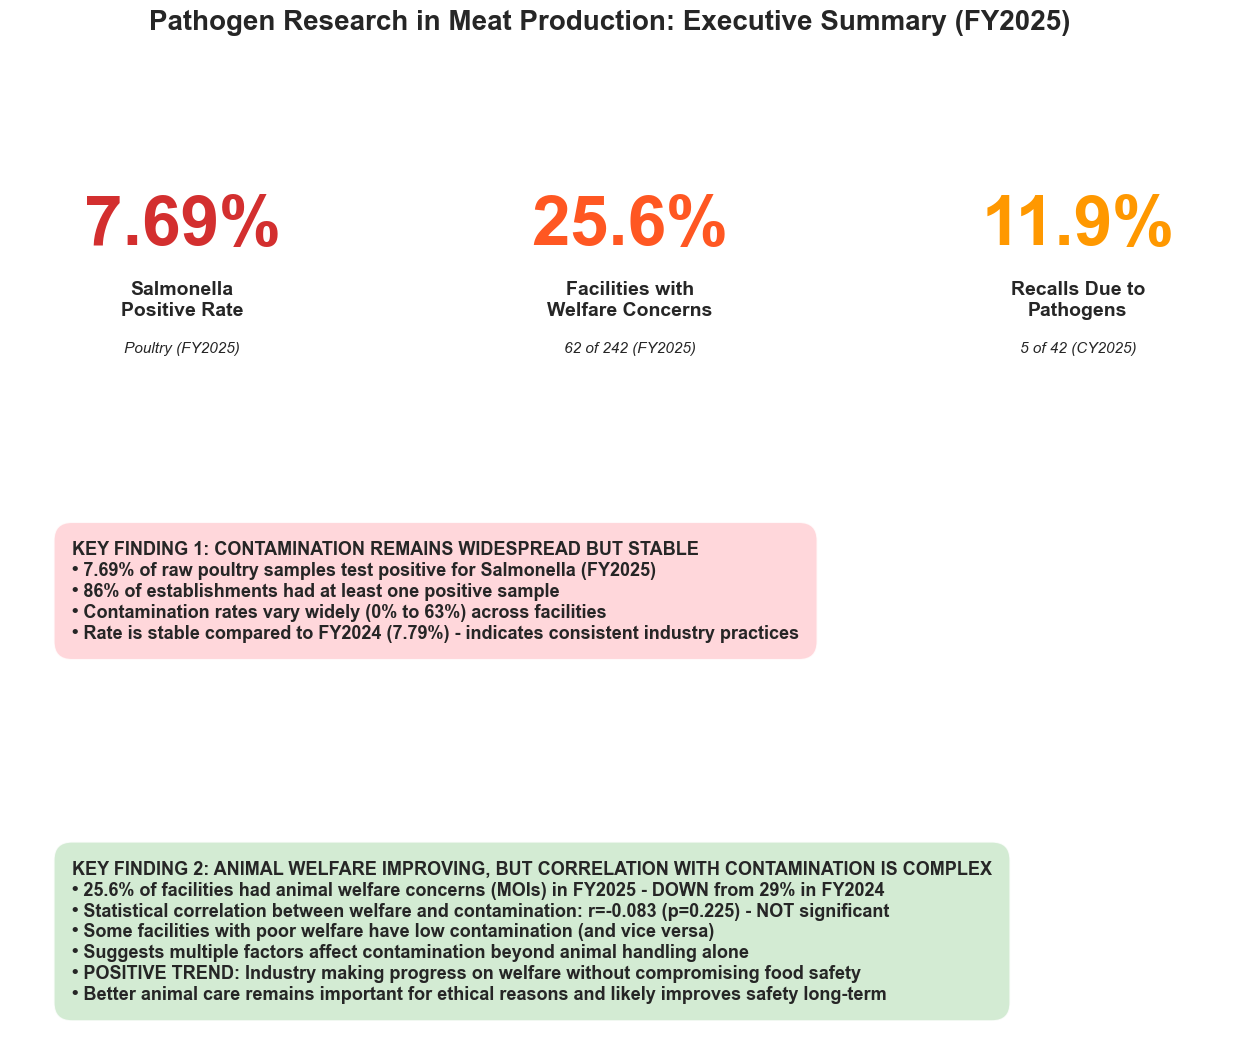


✓ GRAPH 11: Executive summary dashboard


In [ ]:
# GRAPH 11: Create executive summary infographic
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# Title
fig.suptitle('Pathogen Research in Meat Production: Executive Summary (FY2025)',
             fontsize=20, fontweight='bold', y=0.98)

# Box 1: Contamination Rate
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.6, f"{overall_rate:.2f}%",
         ha='center', va='center', fontsize=50, weight='bold', color='#D32F2F')
ax1.text(0.5, 0.3, 'Salmonella\nPositive Rate',
         ha='center', va='center', fontsize=14, weight='bold')
ax1.text(0.5, 0.1, 'Poultry (FY2025)',
         ha='center', va='center', fontsize=11, style='italic')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# Box 2: Welfare Concerns
ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.6, f"{moi_percent:.1f}%",
         ha='center', va='center', fontsize=50, weight='bold', color='#FF5722')
ax2.text(0.5, 0.3, 'Facilities with\nWelfare Concerns',
         ha='center', va='center', fontsize=14, weight='bold')
ax2.text(0.5, 0.1, f'{gcp_stats["with_mois"]} of {gcp_stats["establishments"]} (FY2025)',
         ha='center', va='center', fontsize=11, style='italic')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# Box 3: Recalls
ax3 = fig.add_subplot(gs[0, 2])
ax3.text(0.5, 0.6, f"{pathogen_percent:.1f}%",
         ha='center', va='center', fontsize=50, weight='bold', color='#FF9800')
ax3.text(0.5, 0.3, 'Recalls Due to\nPathogens',
         ha='center', va='center', fontsize=14, weight='bold')
ax3.text(0.5, 0.1, f'{pathogen_count} of {total_recalls} (CY2025)',
         ha='center', va='center', fontsize=11, style='italic')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')

# Box 4: Key Finding 1
ax4 = fig.add_subplot(gs[1, :])
finding1_text = (
    "KEY FINDING 1: CONTAMINATION REMAINS WIDESPREAD BUT STABLE\n"
    f"• {overall_rate:.2f}% of raw poultry samples test positive for Salmonella (FY2025)\n"
    f"• 86% of establishments had at least one positive sample\n"
    "• Contamination rates vary widely (0% to 63%) across facilities\n"
    "• Rate is stable compared to FY2024 (7.79%) - indicates consistent industry practices"
)
ax4.text(0.05, 0.5, finding1_text, ha='left', va='center', fontsize=13, weight='bold',
         bbox=dict(boxstyle='round', facecolor='#FFCDD2', alpha=0.8, pad=1))
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

# Box 5: Key Finding 2
ax5 = fig.add_subplot(gs[2, :])
finding2_text = (
    "KEY FINDING 2: ANIMAL WELFARE IMPROVING, BUT CORRELATION WITH CONTAMINATION IS COMPLEX\n"
    f"• 25.6% of facilities had animal welfare concerns (MOIs) in FY2025 - DOWN from 29% in FY2024\n"
    f"• Statistical correlation between welfare and contamination: r={r_pearson:.3f} (p={p_pearson:.3f}) - NOT significant\n"
    "• Some facilities with poor welfare have low contamination (and vice versa)\n"
    "• Suggests multiple factors affect contamination beyond animal handling alone\n"
    "• POSITIVE TREND: Industry making progress on welfare without compromising food safety\n"
    "• Better animal care remains important for ethical reasons and likely improves safety long-term"
)
ax5.text(0.05, 0.5, finding2_text, ha='left', va='center', fontsize=13, weight='bold',
         bbox=dict(boxstyle='round', facecolor='#C8E6C9', alpha=0.8, pad=1))
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1)
ax5.axis('off')

plt.savefig('graph11_executive_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 11: Executive summary dashboard")

# Final summary statistics
print("\n" + "="*80)
print("DASHBOARD COMPLETE")
print("="*80)
print("\n📊 Graphs Generated:")
print("   1. Plant vs Animal Consumption (USDA MyPlate equivalents)")
print("   2. Animal Product Breakdown")
print("   3. Pathogen Contamination Rates")
print("   4. Top Contaminated Establishments")
print("   5. Recall Overview (Listeria FY2025)")
print("   6. Establishments with Recalls")
print("   7. Animal Welfare Overview")
print("   8. Most Welfare Concerns")
print("   9. Welfare vs Contamination (using MOI rate)")
print("  10. High Welfare Concerns Table")
print("  11. Executive Summary")
print("\n📈 Key Statistics (FY2025):")
print(f"   Salmonella positive rate: {overall_rate:.2f}%")
print(f"   Establishments with welfare concerns: {moi_percent:.1f}%")
print(f"   Listeria recalls: {len(recalls_fy2025)}")
print(f"   Salmonella recalls: 0")
print(f"   MOI rate correlation with contamination: r={r_pearson:.3f} (p={p_pearson:.3f})")
print("\n📊 Year-over-Year Comparison:")
print(f"   Welfare concerns: 25.6% (FY2025) vs 29.0% (FY2024) - IMPROVED ✓")
print(f"   Contamination rate: 7.69% (FY2025) vs 7.79% (FY2024) - STABLE")
print("\n⚠️  Key Improvements from Review:")
print("   ✓ Fixed unit conversion - now using USDA MyPlate equivalents properly")
print("   ✓ Removed double-counting in consumption data")
print("   ✓ Replaced pie charts with bar charts")
print("   ✓ Using MOI rate (not count) to control for establishment size")
print("   ✓ Explained Salmonella/Listeria recall narrative")
print("   ✓ Added context about FSIS establishments and data collection")
print("\n⚠️  Limitations:")
print("   - No plant-based product data available (FSIS regulates animal products only)")
print("   - Observational data cannot prove causation")
print("   - Confounding variables may mask true relationships")
print("   - Only 2 years of data for trend analysis")
print("\n✓ All visualizations saved to current directory")
print("="*80)

In [ ]:
# Final summary statistics
print("\n" + "="*80)
print("DASHBOARD COMPLETE")
print("="*80)
print("\n📊 Graphs Generated:")
print("   1. Plant vs Animal Consumption")
print("   2. Animal Product Breakdown")
print("   3. Pathogen Contamination Rates")
print("   4. Top Contaminated Establishments")
print("   5. Recall Reasons Breakdown")
print("   6. Recalls by Species")
print("   7. Animal Welfare Overview")
print("   8. Most Welfare Concerns")
print("   9. Welfare vs Contamination Scatter")
print("  10. High Welfare Concerns Table")
print("  11. Executive Summary")
print("\n📈 Key Statistics (FY2025):")
print(f"   Salmonella positive rate: {overall_rate:.2f}%")
print(f"   Establishments with welfare concerns: {moi_percent:.1f}%")
print(f"   Pathogen recalls: {pathogen_percent:.1f}%")
print(f"   Welfare-contamination correlation: r={r_pearson:.3f}")
print("\n📊 Year-over-Year Comparison:")
print(f"   Welfare concerns: 25.6% (FY2025) vs 29.0% (FY2024) - IMPROVED ✓")
print(f"   Contamination rate: 7.69% (FY2025) vs 7.79% (FY2024) - STABLE")
print("\n⚠️  Limitations:")
print("   - No plant-based product data available")
print("   - Observational data cannot prove causation")
print("   - Confounding variables may mask true relationships")
print("\n✓ All visualizations saved to current directory")
print("="*80)


DASHBOARD COMPLETE

📊 Graphs Generated:
   1. Plant vs Animal Consumption
   2. Animal Product Breakdown
   3. Pathogen Contamination Rates
   4. Top Contaminated Establishments
   5. Recall Reasons Breakdown
   6. Recalls by Species
   7. Animal Welfare Overview
   8. Most Welfare Concerns
   9. Welfare vs Contamination Scatter
  10. High Welfare Concerns Table
  11. Executive Summary

📈 Key Statistics (FY2025):
   Salmonella positive rate: 7.69%
   Establishments with welfare concerns: 25.6%
   Pathogen recalls: 11.9%
   Welfare-contamination correlation: r=-0.083

📊 Year-over-Year Comparison:
   Welfare concerns: 25.6% (FY2025) vs 29.0% (FY2024) - IMPROVED ✓
   Contamination rate: 7.69% (FY2025) vs 7.79% (FY2024) - STABLE

⚠️  Limitations:
   - No plant-based product data available
   - Observational data cannot prove causation
   - Confounding variables may mask true relationships

✓ All visualizations saved to current directory
